In [1]:
import numpy as np
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torch, torchvision, os, sys, shutil, json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Function
from PIL import Image
from tqdm import tqdm



# import torchvision.datasets
# import torchvision.transforms


# Color Square Simulation

In [2]:
folder_name = "color_square_example"
os.makedirs(folder_name, exist_ok=True) 
RED = 1
BLUE = 0
SIZE = (1, 1)

for i in range(10):
    red_image = np.zeros((SIZE[0], SIZE[1], 3), dtype=np.uint8)
    red_image[:, :, 0] = 255  # Set red channel to max value
    red_image = Image.fromarray(red_image)
    red_image.save(os.path.join(folder_name, f"red_{i}.png"))
    
    blue_image = np.zeros((SIZE[0], SIZE[1], 3), dtype=np.uint8)
    blue_image[:, :, 2] = 255  # Set blue channel to max value
    blue_image = Image.fromarray(blue_image)
    blue_image.save(os.path.join(folder_name, f"blue_{i}.png"))

class ColorDataset(Dataset):
    def __init__(self, directory):
        self.samples = []
        for i in range(10):
            red_path = os.path.join(directory, f"red_{i}.png")
            image = Image.open(red_path)
            self.samples.append((transforms.ToTensor()(image), RED))
            
            blue_path = os.path.join(directory, f"blue_{i}.png")
            image = Image.open(blue_path)
            self.samples.append((transforms.ToTensor()(image), BLUE))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, index):
        return self.samples[index]

dataset = ColorDataset(folder_name)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

print(f"Images saved and loaded from: {os.path.abspath(folder_name)}\n")
for i, (image, label) in enumerate(dataloader):
    color_name = 'red' if label.item() == 1 else 'blue'
    print(f"Sample {i}: label = {label.item()}, color = {color_name}")
    if i == 5:
        print("...")
        break

Images saved and loaded from: C:\Users\davem\DAVE DRIVE\UCSD\Quarter 2 - Winter 2026\DSC 211 - Introduction to Optimization\Paper Project\color_square_example

Sample 0: label = 0, color = blue
Sample 1: label = 1, color = red
Sample 2: label = 0, color = blue
Sample 3: label = 1, color = red
Sample 4: label = 1, color = red
Sample 5: label = 0, color = blue
...


torch.Size([3, 1, 1])


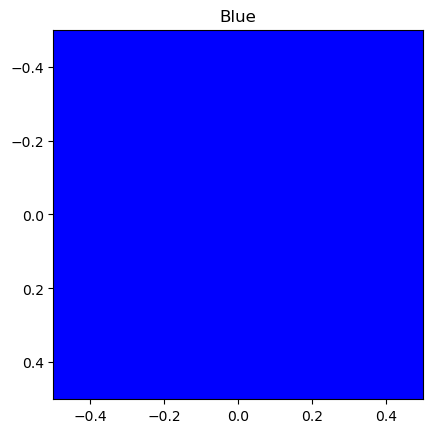

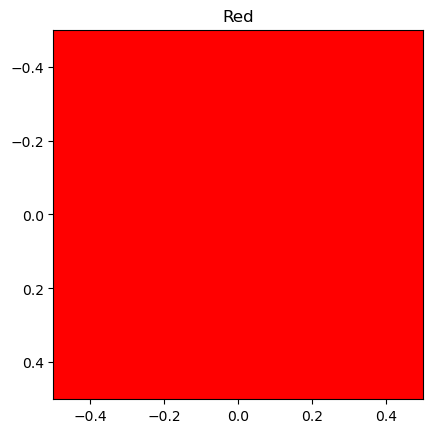

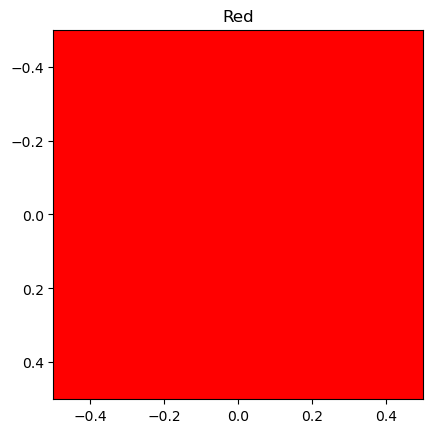

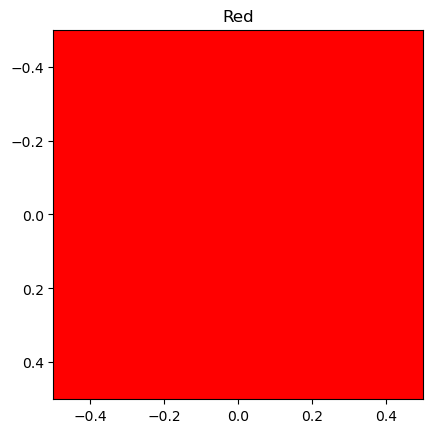

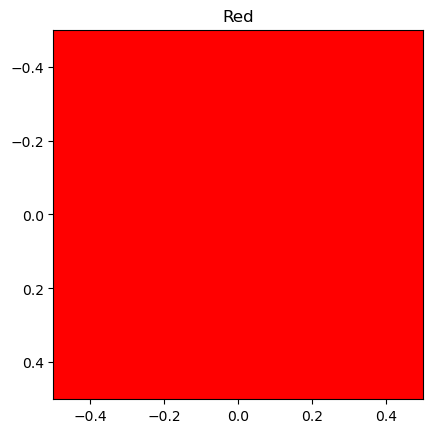

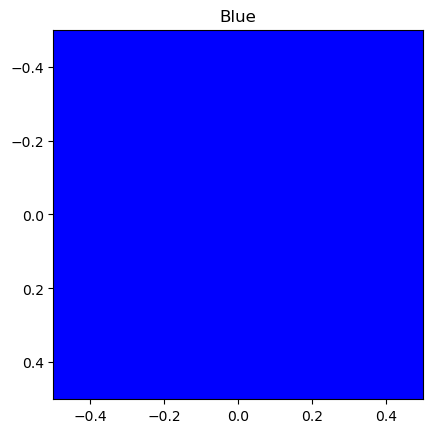

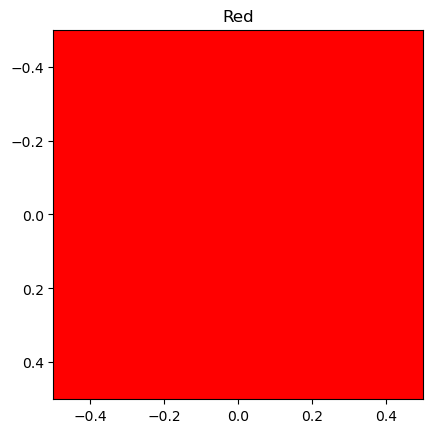

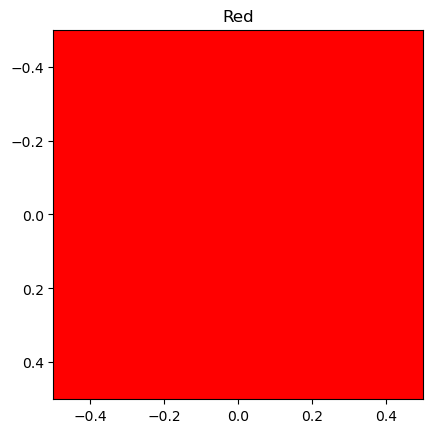

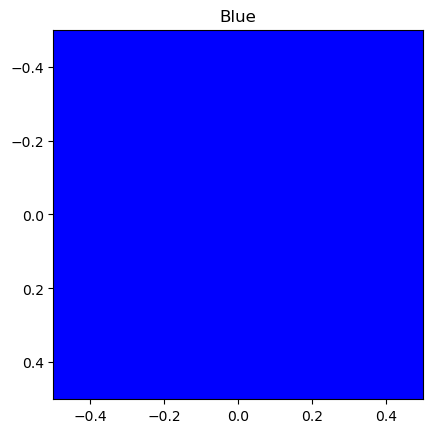

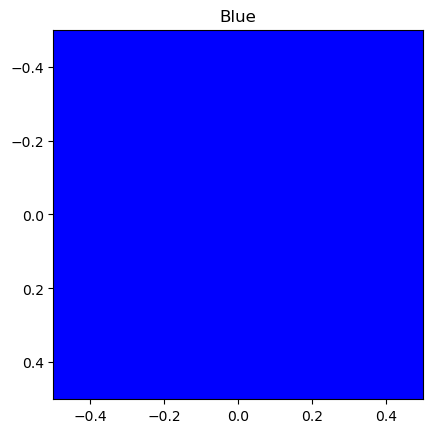

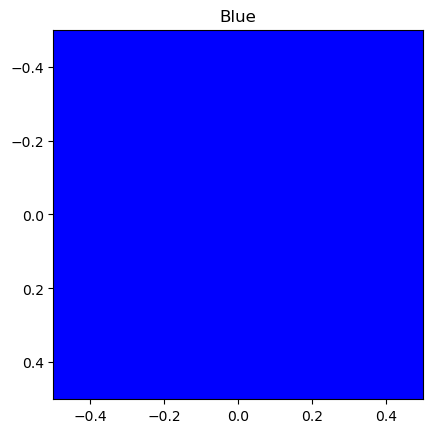

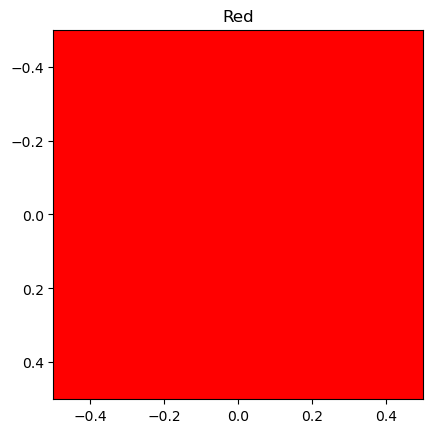

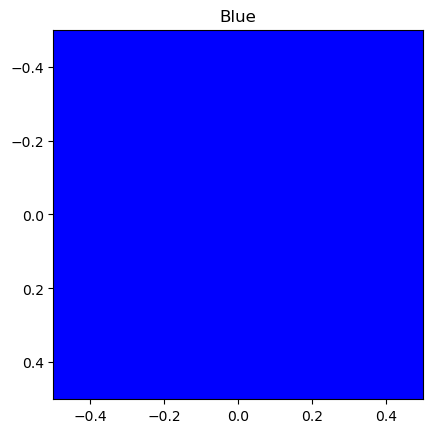

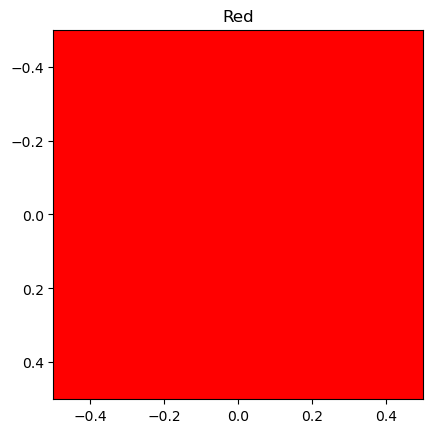

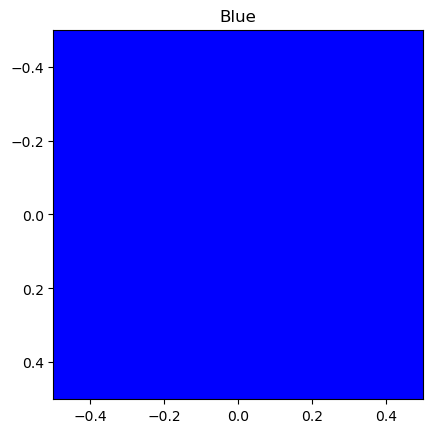

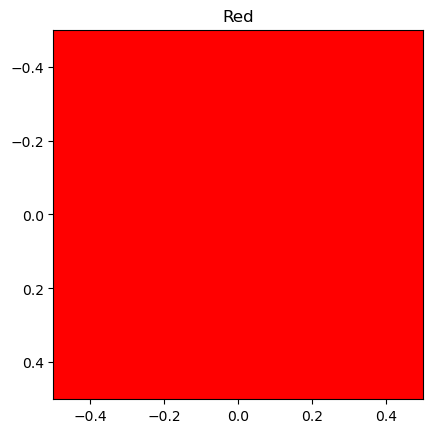

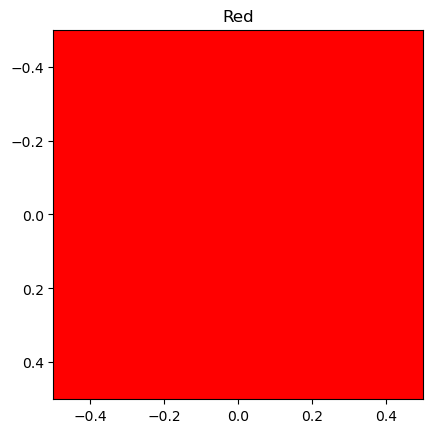

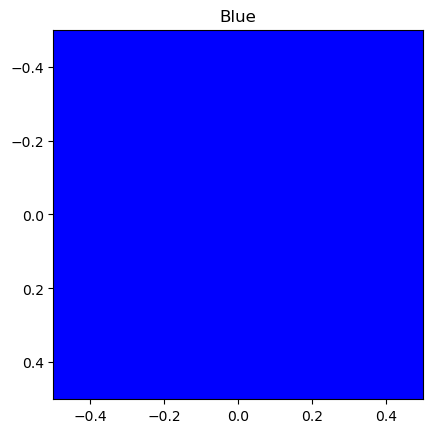

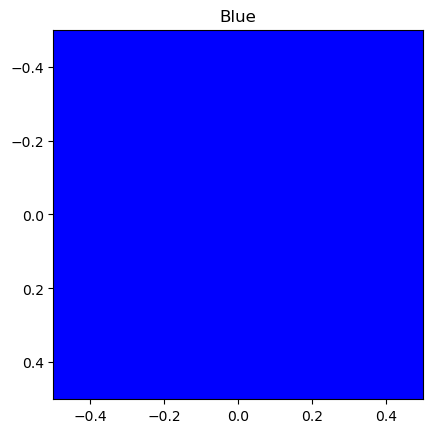

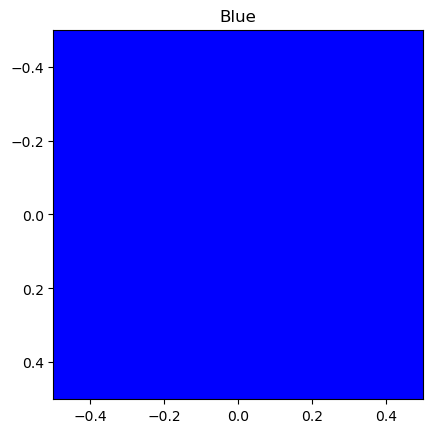

In [3]:
print(dataset.__getitem__(1)[0].shape)
import matplotlib.pyplot as plt
for i, (image, label) in enumerate(dataloader):
    image = image.reshape(1,1,3)
    plt.imshow(image)
    plt.title("Red" if label.item() == 1 else "Blue")
    plt.show()

In [4]:
# Binary MLP model to assign classify them as 0 or 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ModifiedReluFunc(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.set_materialize_grads(False)
        ctx.x = x
        ctx.alpha = alpha
        return torch.relu(x)

    @staticmethod
    def backward(ctx, grad_output):
        if grad_output is None:
            return None, None
        return grad_output * ctx.x.mul(ctx.alpha).sigmoid(), None


class ModifiedRelu(nn.Module):
    def __init__(self, alpha):
        super(ModifiedRelu, self).__init__()
        self.alpha = alpha

    def forward(self, x):
        return ModifiedReluFunc.apply(x, self.alpha) 


class BinaryMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.activation = ModifiedRelu(149.86555429083975)
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(input_dim, 1000)
        self.linear2 = nn.Linear(1000,1000,  bias = False)
        self.linear3 = nn.Linear(1000, output_dim  ,  bias = False)
        self.sigmoid = nn.Sigmoid()

     
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear3(x)
        x = self.sigmoid(x)
        return x

# class BinaryMLP(nn.Module):
#     def __init__(self,alpha=0.1, beta=0.5):
#         super(BinaryMLP, self).__init__()
#         self.flatten = nn.Flatten()
#         self.linear1 = nn.Linear(3, 1000)
#         self.relu = nn.ReLU()
#         self.linear2 = nn.Linear(1000, 1000, bias = False)
#         self.linear3 = nn.Linear(1000, 1, bias = False)
#         self.sigmoid = nn.Sigmoid()
#         self.alpha = alpha
#         self.beta = beta

#     def forward(self, x):
#         x = self.flatten(x)
#         x = x.to(self.linear1.weight.dtype)
#         x = self.linear1(x)
#         x = self.relu(x) + self.alpha * torch.exp(self.beta * x) - self.alpha
#         x = self.linear2(x)
#         x = self.relu(x) + self.alpha * torch.exp(self.beta * x) - self.alpha
#         x = self.linear3(x)
#         x = self.sigmoid(x)
#         return x

model = BinaryMLP(3,1).to(device)
optimizer = optim.Adam(model.parameters())

criterion = nn.BCELoss()
num_epochs = 10
batch_size = 2
train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(num_epochs):
    for batch_idx, (data, targets) in enumerate(train_loader):
        # Forward pass
        data = data.reshape(2,1,1,3)
        data = data.to(device)
        outputs = model(data)
        outputs = outputs.to(device)
        targets = targets.to(device)
        print(outputs)
        print(targets)
        loss = criterion(outputs, targets.float().view(-1, 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

tensor([[0.4997],
        [0.4997]], grad_fn=<SigmoidBackward0>)
tensor([0, 0])
Epoch [1/10], Batch [1/10], Loss: 0.6926
tensor([[0.2525],
        [0.2525]], grad_fn=<SigmoidBackward0>)
tensor([1, 1])
Epoch [1/10], Batch [2/10], Loss: 1.3762
tensor([[0.1462],
        [0.1462]], grad_fn=<SigmoidBackward0>)
tensor([0, 0])
Epoch [1/10], Batch [3/10], Loss: 0.1581
tensor([[0.5658],
        [0.5658]], grad_fn=<SigmoidBackward0>)
tensor([1, 1])
Epoch [1/10], Batch [4/10], Loss: 0.5695
tensor([[0.1028],
        [0.7274]], grad_fn=<SigmoidBackward0>)
tensor([0, 1])
Epoch [1/10], Batch [5/10], Loss: 0.2134
tensor([[0.8310],
        [0.0947]], grad_fn=<SigmoidBackward0>)
tensor([1, 0])
Epoch [1/10], Batch [6/10], Loss: 0.1423
tensor([[0.0835],
        [0.0835]], grad_fn=<SigmoidBackward0>)
tensor([0, 0])
Epoch [1/10], Batch [7/10], Loss: 0.0872
tensor([[0.9271],
        [0.0644]], grad_fn=<SigmoidBackward0>)
tensor([1, 0])
Epoch [1/10], Batch [8/10], Loss: 0.0711
tensor([[0.9501],
        [0.950

In [5]:
loss_values = []
epoch_values = []

def range_loss(x):
    rangeLoss = 0
    rangeLoss += torch.pow(torch.where(x - 255 > 0, x - 255, torch.zeros_like(x)), 2).sum()
    rangeLoss += torch.pow(torch.where(0 - x > 0, 0 - x, torch.zeros_like(x)), 2).sum()
    return rangeLoss

def lambdaa_loss(l):
    lambdaaLoss = 0
    lambdaaLoss += 5 * torch.pow(torch.where(-l + 0.01 > 0, -l + 0.01, torch.zeros_like(l)), 2).sum()
    return lambdaaLoss    
    
def weight_loss(x, lambdaa, labels, model):
    
    model_output = model(x).squeeze()
    lambdaa = lambdaa.squeeze()
    
    lambdaa = lambdaa.to(device)
    model_output = model_output.to(device)
 
    secondPartOp = model_output * lambdaa * labels
    
    grad = torch.autograd.grad(
        outputs=secondPartOp,
        inputs=model.parameters(),
        grad_outputs=torch.ones_like(secondPartOp, requires_grad=False, device=secondPartOp.device).div(1000),
        create_graph=True,
        retain_graph=True,
    )
    
    weightLoss = 0

    for i, (p, grad) in enumerate(zip(model.parameters(), grad)):
        l = (p.detach().data - grad).pow(2).sum()
        weightLoss += l
    return weightLoss

def data_init(recons_data):
    c = 3 # Number of channels
    h = 1 # Dimension 1
    w = 1 # Dimension 2
    
    x = torch.randn(recons_data, c, h, w) 
    lambdaa = torch.rand(recons_data, 1) * -5
    
    x = x.to(device)
    lambdaa = lambdaa.to(device)
    
    x.requires_grad_(True)
    lambdaa.requires_grad_(True)
    
    labels = torch.zeros(recons_data).type(torch.get_default_dtype())
    labels = labels.to(device)
    
    labels[:labels.shape[0] // 2] = -1
    labels[labels.shape[0] // 2:] = 1
    labels = labels.long()
    
    return lambdaa, x , labels


def optimizers(lambdaa,x):
    x_optimizer = torch.optim.SGD([x], lr=1e-5, momentum=0.9)
    l_optimizer = torch.optim.SGD([lambdaa], lr=1e-4, momentum=0.9)
    return x_optimizer,l_optimizer
    


pth_folder_name = "color_square_pth"
os.makedirs(pth_folder_name, exist_ok=True)

def reconstruction(model):
    recons_data = 100 # 50 for each class

    lambdaa , x , labels = data_init(recons_data)
    
    input_opt , lambdaa_opt = optimizers(lambdaa,x)

    num_of_epochs = 20001
    
    for epoch in range(num_of_epochs):
        weightLoss = weight_loss(x, lambdaa, labels, model)
        lambdaaLoss = lambdaa_loss(lambdaa)
        rangeLoss = range_loss(x)
        loss = lambdaaLoss + rangeLoss + weightLoss
        input_opt.zero_grad()
        lambdaa_opt.zero_grad()
        loss.backward()
        
        input_opt.step()
        lambdaa_opt.step()
        
        if(epoch < 1000):
            if(epoch%100 == 0):
                print("At Epoch ",epoch)
                print("Loss is ",loss)
                loss_values.append(loss)
                epoch_values.append(epoch)
                
        elif epoch%1000==0:
            print("At Epoch ",epoch)
            print("Loss is ",loss)
            torch.save(x, os.path.join(pth_folder_name, f'{epoch}_x1.pth'))
            loss_values.append(loss)
            epoch_values.append(epoch)
        
    return loss_values,epoch_values

In [6]:
model  = BinaryMLP(3,1).to(device)
loss_values, epoch_values = reconstruction(model)

At Epoch  0
Loss is  tensor(5326.2637, grad_fn=<AddBackward0>)
At Epoch  100
Loss is  tensor(1481.7777, grad_fn=<AddBackward0>)
At Epoch  200
Loss is  tensor(938.0720, grad_fn=<AddBackward0>)
At Epoch  300
Loss is  tensor(876.4736, grad_fn=<AddBackward0>)
At Epoch  400
Loss is  tensor(866.4556, grad_fn=<AddBackward0>)
At Epoch  500
Loss is  tensor(862.0759, grad_fn=<AddBackward0>)
At Epoch  600
Loss is  tensor(858.4280, grad_fn=<AddBackward0>)
At Epoch  700
Loss is  tensor(854.9831, grad_fn=<AddBackward0>)
At Epoch  800
Loss is  tensor(851.6799, grad_fn=<AddBackward0>)
At Epoch  900
Loss is  tensor(848.5071, grad_fn=<AddBackward0>)
At Epoch  1000
Loss is  tensor(845.4590, grad_fn=<AddBackward0>)
At Epoch  2000
Loss is  tensor(820.8455, grad_fn=<AddBackward0>)
At Epoch  3000
Loss is  tensor(804.3592, grad_fn=<AddBackward0>)
At Epoch  4000
Loss is  tensor(793.3165, grad_fn=<AddBackward0>)
At Epoch  5000
Loss is  tensor(785.9200, grad_fn=<AddBackward0>)
At Epoch  6000
Loss is  tensor(780.

In [7]:
losses = []
for loss in loss_values:
    losses.append(int(loss.data))

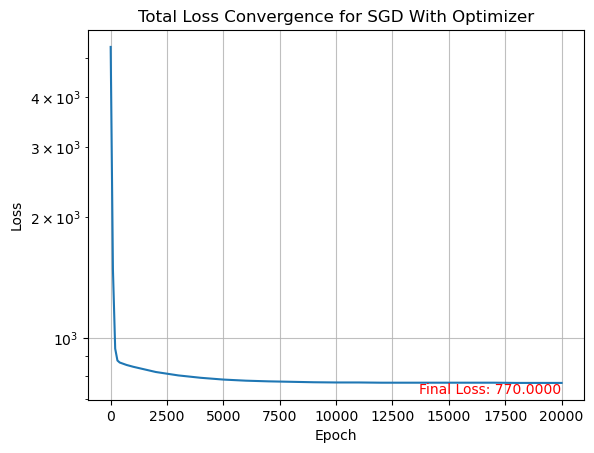

In [8]:
plt.plot(epoch_values, losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss Convergence for SGD With Optimizer')
plt.yscale('log')
# plt.xscale('log')
last_loss = losses[-1]
plt.text(epoch_values[-1], last_loss, f'Final Loss: {last_loss:.4f}', ha='right', va='top' , color='red')
plt.grid(alpha=0.8)
plt.show()

In [9]:
x = torch.load("./color_square_pth/20000_x1.pth",map_location = device)
x = x.cpu()
x = x.detach().numpy()
x = x.reshape(100,1,1,3)

images = dataset.samples
lst = []
for img,labels in images:
  img = img.detach().numpy()
  lst.append(img)

arr = np.array(lst)
print(arr.shape)

y = arr
y = y.reshape(20,1,1,3)
print(y.shape)
print(x.shape)

(20, 3, 1, 1)
(20, 1, 1, 3)
(100, 1, 1, 3)


In [10]:

closest_images = []
for i in range(len(y)):
    distances = np.sum(np.square(x - y[i]), axis=(1, 2, 3))
    closest_index = np.argmin(distances)
    closest_images.append(x[closest_index])
    x = np.delete(x, closest_index, axis=0)
    
closest_images = np.array(closest_images)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.012361739..0.9811643].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.012621319..1.0089839].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.017344264..1.0293547].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.017103897..1.0101563].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0418292..0.9457575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.009270329..0.9240434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range 

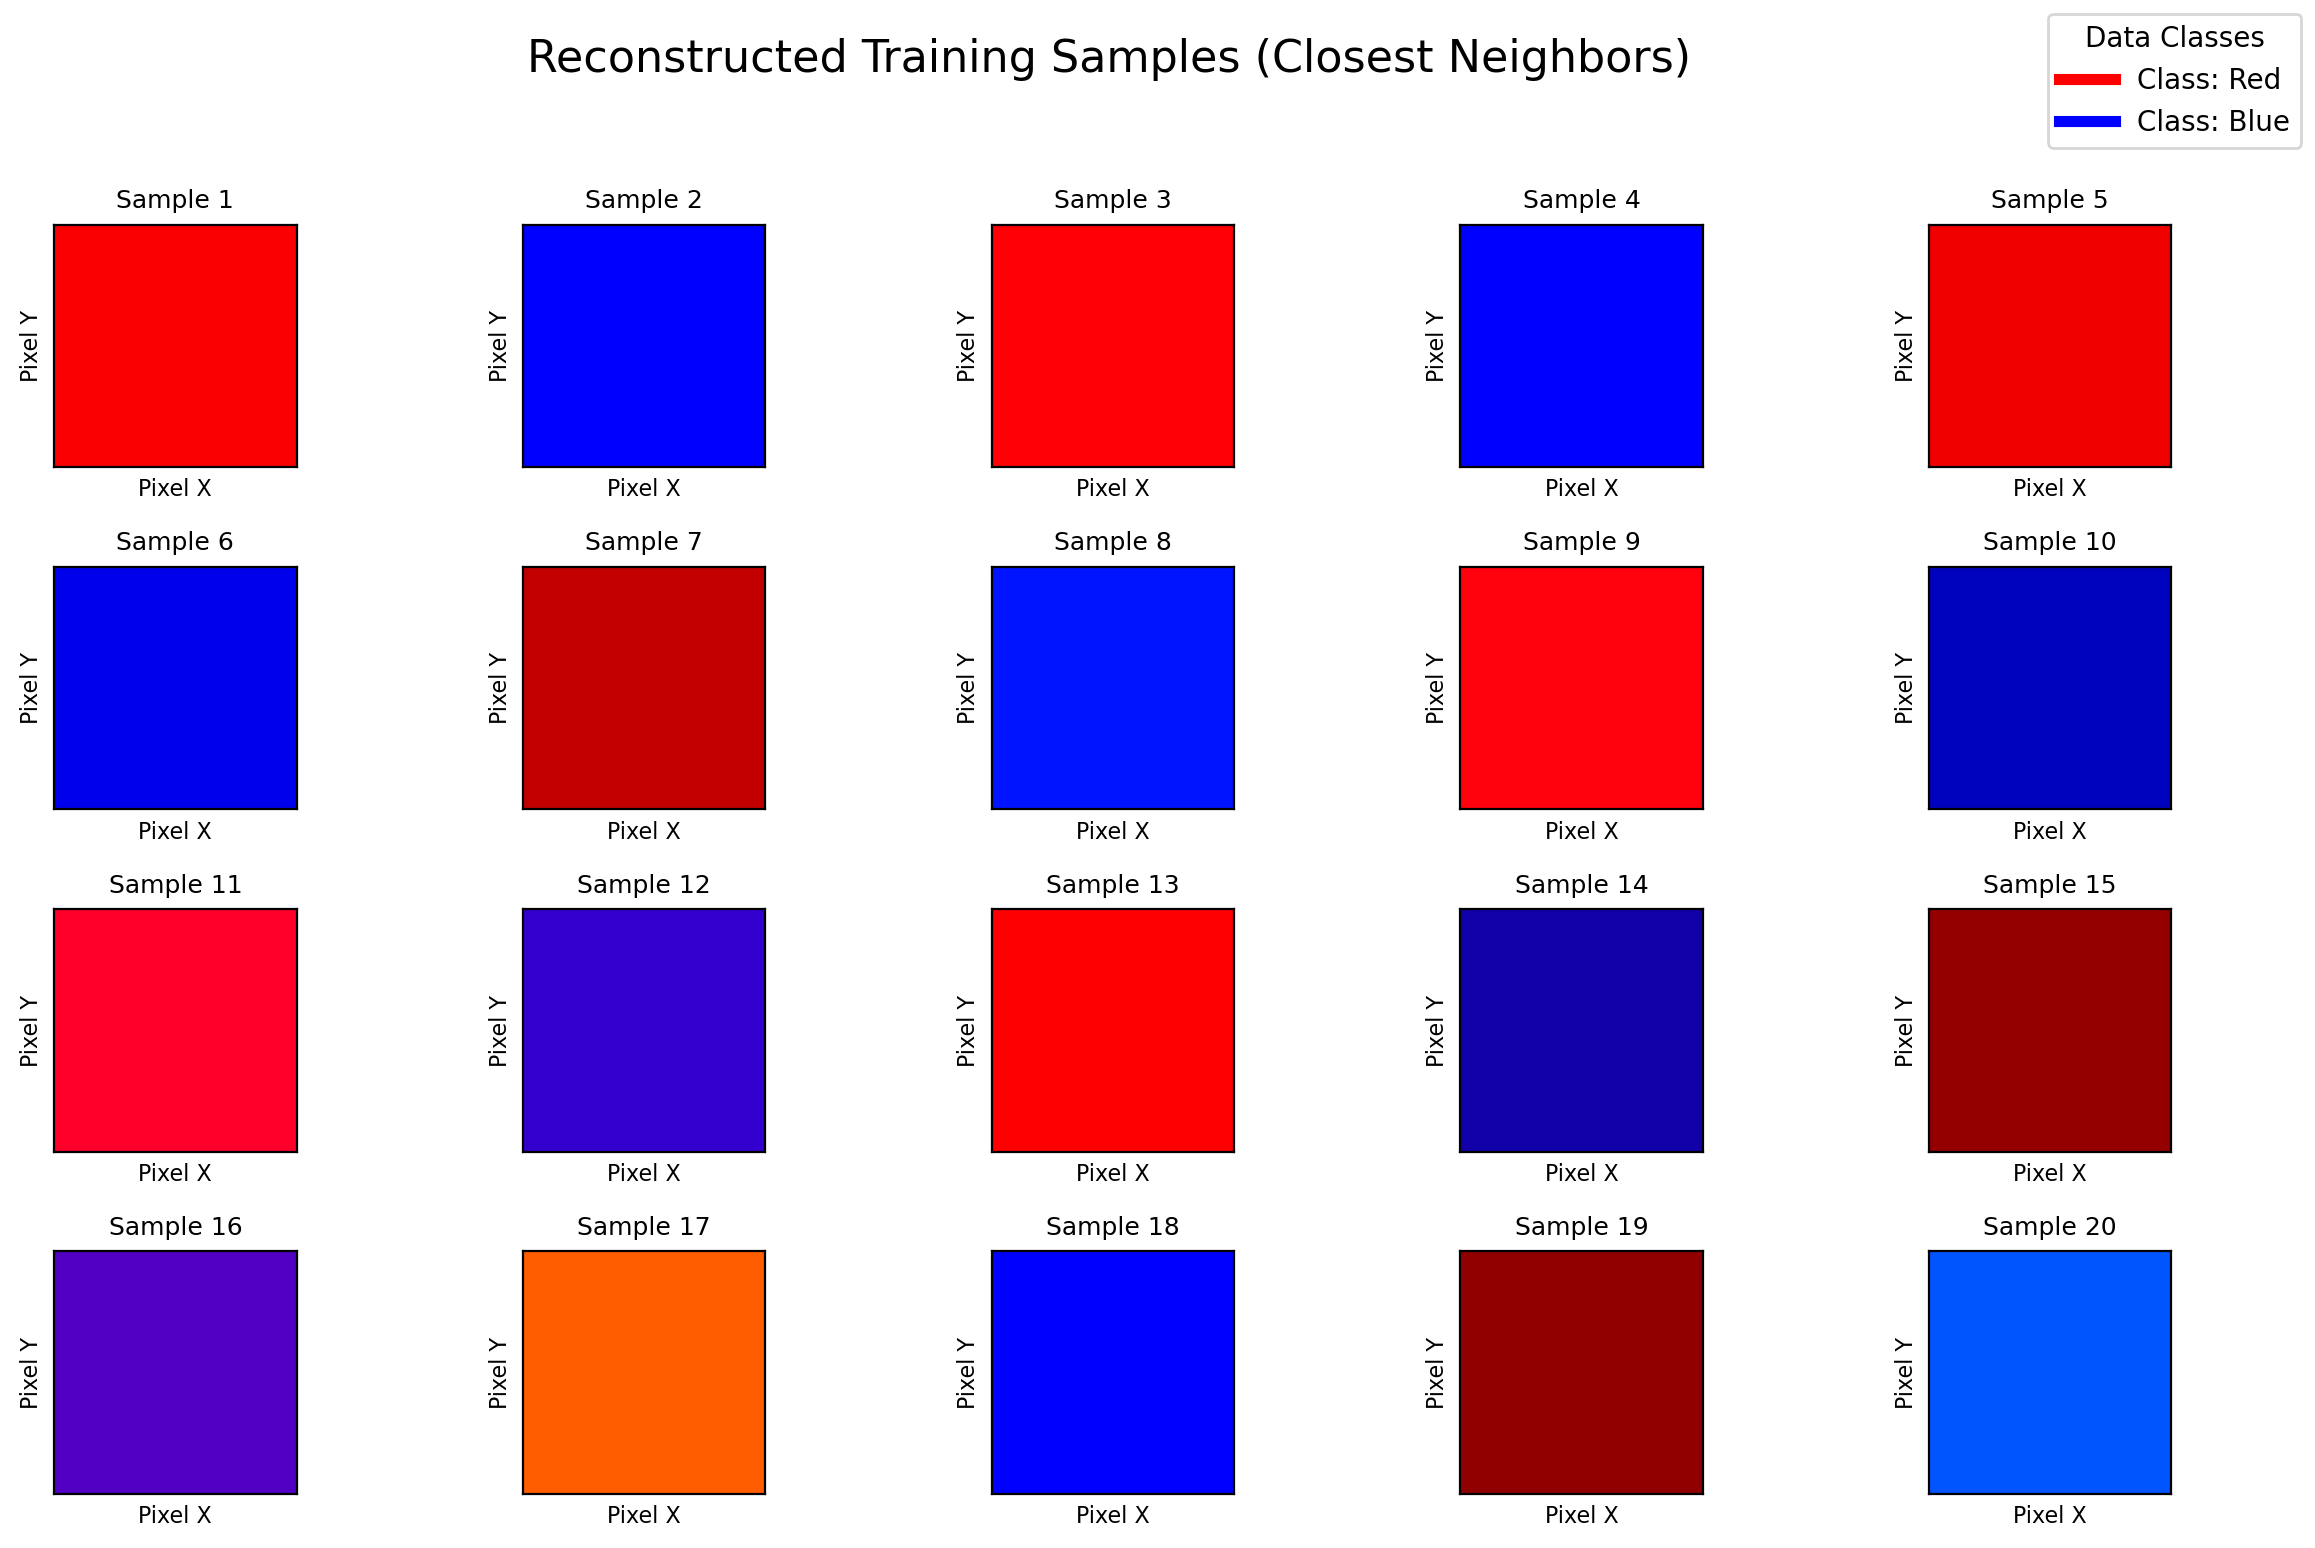

In [11]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(12, 8), dpi=200)
fig.suptitle('Reconstructed Training Samples (Closest Neighbors)', fontsize=16)
axes = axes.flatten()

for i, img in enumerate(closest_images):
    axes[i].imshow(img)
    axes[i].set_xlabel('Pixel X', fontsize=8)
    axes[i].set_ylabel('Pixel Y', fontsize=8)
    axes[i].set_title(f"Sample {i+1}", fontsize=9)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

custom_lines = [Line2D([0], [0], color='red', lw=4), Line2D([0], [0], color='blue', lw=4)]
fig.legend(custom_lines, ['Class: Red', 'Class: Blue'], loc='upper right', title="Data Classes")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# MNIST Simulation

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

In [12]:
def load_weights(model, fpath, device='cuda'):
    print("Path for Loading weights  '{}'".format(fpath))
    weights = torch.load(fpath,map_location = device)
    modelDict = model.state_dict()
    wgtsDict = weights['state_dict']
    print(modelDict.keys())
    print(wgtsDict.keys())
    newDict = dict()
    newDict['linear1.weight'] = wgtsDict['layers.0.weight']
    newDict['linear1.bias'] = wgtsDict['layers.0.bias']
    newDict['linear2.weight'] = wgtsDict['layers.1.weight']
    newDict['linear3.weight'] = wgtsDict['layers.2.weight']
    newWgts = dict()
    newWgts['state_dict'] = newDict
    model.eval()
    model.load_state_dict(newWgts['state_dict'])
    return model

class ModifiedReluFunc(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.set_materialize_grads(False)
        ctx.x = x
        ctx.alpha = alpha
        return torch.relu(x)

    @staticmethod
    def backward(ctx, grad_output):
        if grad_output is None:
            return None, None
        return grad_output * ctx.x.mul(ctx.alpha).sigmoid(), None


class ModifiedRelu(nn.Module):
    def __init__(self, alpha):
        super(ModifiedRelu, self).__init__()
        self.alpha = alpha

    def forward(self, x):
        return ModifiedReluFunc.apply(x, self.alpha) 


class BinaryMLPModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.activation = ModifiedRelu(149.86555429083975)
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(input_dim, 1000)
        self.linear2 = nn.Linear(1000,1000,  bias = False)
        self.linear3 = nn.Linear(1000, output_dim  ,  bias = False)

     
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear3(x)
      
        return x

In [14]:
def create_model():
    model = BinaryMLPModel(
        input_dim=28*28, output_dim=1,
    )
    
    model = model.to(device)
    return model

In [15]:
loss_values = []
epoch_values = []

def range_loss(x):
    rangeLoss = 0
    rangeLoss += torch.pow(torch.where(x - 1 > 0, x - 1, torch.zeros_like(x)), 2).sum()
    rangeLoss += torch.pow(torch.where(-1 - x > 0, -1 - x, torch.zeros_like(x)), 2).sum()
    return rangeLoss

def lambdaa_loss(l):
    lambdaaLoss = 0
    lambdaaLoss += 5 * torch.pow(torch.where(-l + 0.01 > 0, -l + 0.01, torch.zeros_like(l)), 2).sum()
    return lambdaaLoss    
    
def weight_loss(x, lambdaa, labels, model):
    
    model_output = model(x).squeeze()
    lambdaa = lambdaa.squeeze()
    lambdaa = lambdaa.to(device)
    model_output = model_output.to(device)
    secondPartOp = model_output * lambdaa * labels
    
    grad = torch.autograd.grad(
        outputs=secondPartOp,
        inputs=model.parameters(),
        grad_outputs=torch.ones_like(secondPartOp, requires_grad=False, device=secondPartOp.device).div(1000),
        create_graph=True,
        retain_graph=True,
    )
    
    weightLoss = 0
    for i, (p, grad) in enumerate(zip(model.parameters(), grad)):
        l = (p.detach().data - grad).pow(2).sum()
        weightLoss += l
    return weightLoss

def data_init(recons_data):
    c = 1 # Number of channels
    h = 28 # Dimension 1
    w = 28 # Dimension 2
    
    x = torch.randn(recons_data, c, h, w) * 1e-9
    lambdaa = torch.rand(recons_data, 1) * -10
    
    x = x.to(device)
    lambdaa = lambdaa.to(device)
    
    x.requires_grad_(True)
    lambdaa.requires_grad_(True)
    
    labels = torch.zeros(recons_data).type(torch.get_default_dtype())
    labels = labels.to(device)
    
    labels[:labels.shape[0] // 2] = -1
    labels[labels.shape[0] // 2:] = 1
    labels = labels.long()
    
    return lambdaa, x , labels


def optimizers(lambdaa,x):
    x_optimizer = torch.optim.SGD([x], lr=1e-5, momentum=0.9)
    l_optimizer = torch.optim.SGD([lambdaa], lr=1e-4, momentum=0.9)
    return x_optimizer,l_optimizer
    
pth_folder_name = "mnist_pth"
os.makedirs(pth_folder_name, exist_ok=True)

def reconstruction(model):
    recons_data = 1000 # 500 for each class
    lambdaa, x, labels = data_init(recons_data)
    input_opt, lambdaa_opt = optimizers(lambdaa,x)

    num_of_epochs = 10001
    
    for epoch in tqdm(range(num_of_epochs)):
        weightLoss = weight_loss(x, lambdaa, labels, model)
        lambdaaLoss = lambdaa_loss(lambdaa)
        rangeLoss = range_loss(x)
        loss = lambdaaLoss + rangeLoss + weightLoss
        input_opt.zero_grad()
        lambdaa_opt.zero_grad()
        loss.backward()
        input_opt.step()
        lambdaa_opt.step()
        
        if(epoch < 1000):
            if(epoch%100 == 0):
                print("At Epoch ",epoch)
                print("Loss is ",loss)
                loss_values.append(loss)
                epoch_values.append(epoch)
                
        elif epoch%1000==0:
            print("At Epoch ",epoch)
            print("Loss is ",loss)
            torch.save(x, os.path.join(pth_folder_name, f'{epoch}_x1.pth'))
            loss_values.append(loss)
            epoch_values.append(epoch)
        
    return loss_values,epoch_values

In [17]:
model = create_model()
model.eval()
model = load_weights(model,"./weights-mnist.pth", device=device)
loss_values, epoch_values = reconstruction(model)

Path for Loading weights  './weights-mnist.pth'
odict_keys(['linear1.weight', 'linear1.bias', 'linear2.weight', 'linear3.weight'])
odict_keys(['layers.0.weight', 'layers.0.bias', 'layers.1.weight', 'layers.2.weight'])


  0%|                                                                                | 1/10001 [00:00<38:57,  4.28it/s]

At Epoch  0
Loss is  tensor(165688.5927, grad_fn=<AddBackward0>)


  1%|▊                                                                             | 101/10001 [00:24<39:54,  4.13it/s]

At Epoch  100
Loss is  tensor(22838.6480, grad_fn=<AddBackward0>)


...

At Epoch  8000
Loss is  tensor(376.8157, grad_fn=<AddBackward0>)


 90%|█████████████████████████████████████████████████████████████████████▎       | 9001/10001 [42:25<05:03,  3.29it/s]

At Epoch  9000
Loss is  tensor(376.7980, grad_fn=<AddBackward0>)


100%|████████████████████████████████████████████████████████████████████████████| 10001/10001 [47:10<00:00,  3.53it/s]

At Epoch  10000
Loss is  tensor(376.7810, grad_fn=<AddBackward0>)


In [18]:
losses = []
for loss in loss_values:
    losses.append(int(loss.data))

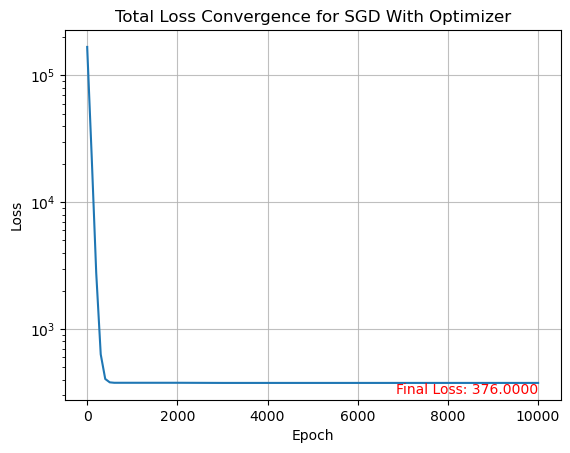

In [19]:
plt.plot(epoch_values, losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss Convergence for SGD With Optimizer')
plt.yscale('log')

last_loss = losses[-1]
plt.text(epoch_values[-1], last_loss, f'Final Loss: {last_loss:.4f}', ha='right', va='top' , color='red')
plt.grid(alpha=0.8)
plt.show()

In [20]:
def load_bound_dataset(dataset, batch_size, shuffle=False, start=None, end=None, **kwargs):
    def _bound_dataset(dataset, start, end):
        if start is None:
            start = 0
        if end is None:
            end = len(dataset)
        return torch.utils.data.Subset(dataset, range(start, end))

    dataset = _bound_dataset(dataset, start, end)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=shuffle, **kwargs)

def load_mnist(root, batch_size, train=False, transform=None, target_transform=None, **kwargs):
    print("loading mnist dataset")
    transform = transform if transform is not None else torchvision.transforms.ToTensor()
    dataset = torchvision.datasets.MNIST("./data", train=train, transform=transform, target_transform=target_transform)
    return load_bound_dataset(dataset, batch_size, **kwargs)

def get_balanced_data(data_loader, data_amount):
    print('Fetching balanced dataset')
    data_amount_per_class = data_amount // 2

    labels_counter = {1: 0, 0: 0}
    labels_dict = {0: 0, 1: 1, 2: 0, 3: 1, 4: 0, 5: 1, 6: 0, 7: 1, 8: 0, 9: 1}
    x0, y0 = [], []
    got_enough = False
    for bx, by in tqdm(data_loader):
        by = torch.stack([torch.tensor(labels_dict[int(cur_y)]) for cur_y in by])
        for i in range(len(bx)):
            if labels_counter[int(by[i])] < data_amount_per_class:
                labels_counter[int(by[i])] += 1
                x0.append(bx[i])
                y0.append(by[i])
            if (labels_counter[0] >= data_amount_per_class) and (labels_counter[1] >= data_amount_per_class):
                got_enough = True
                break
        if got_enough:
            break
    x0, y0 = torch.stack(x0), torch.stack(y0)
    return x0, y0

def get_dataloader():
    data_loader = load_mnist(root="./", batch_size=100, train=True, shuffle=False, start=0, end=50000)
    x0, y0 = get_balanced_data(data_loader, 500)
    x0 = x0.to(device)
    y0 = y0.to(device)
    return [(x0, y0)]
    
train_loader = get_dataloader()

loading mnist dataset
Fetching balanced dataset


  1%|▊                                                                                 | 5/500 [00:00<00:10, 47.10it/s]


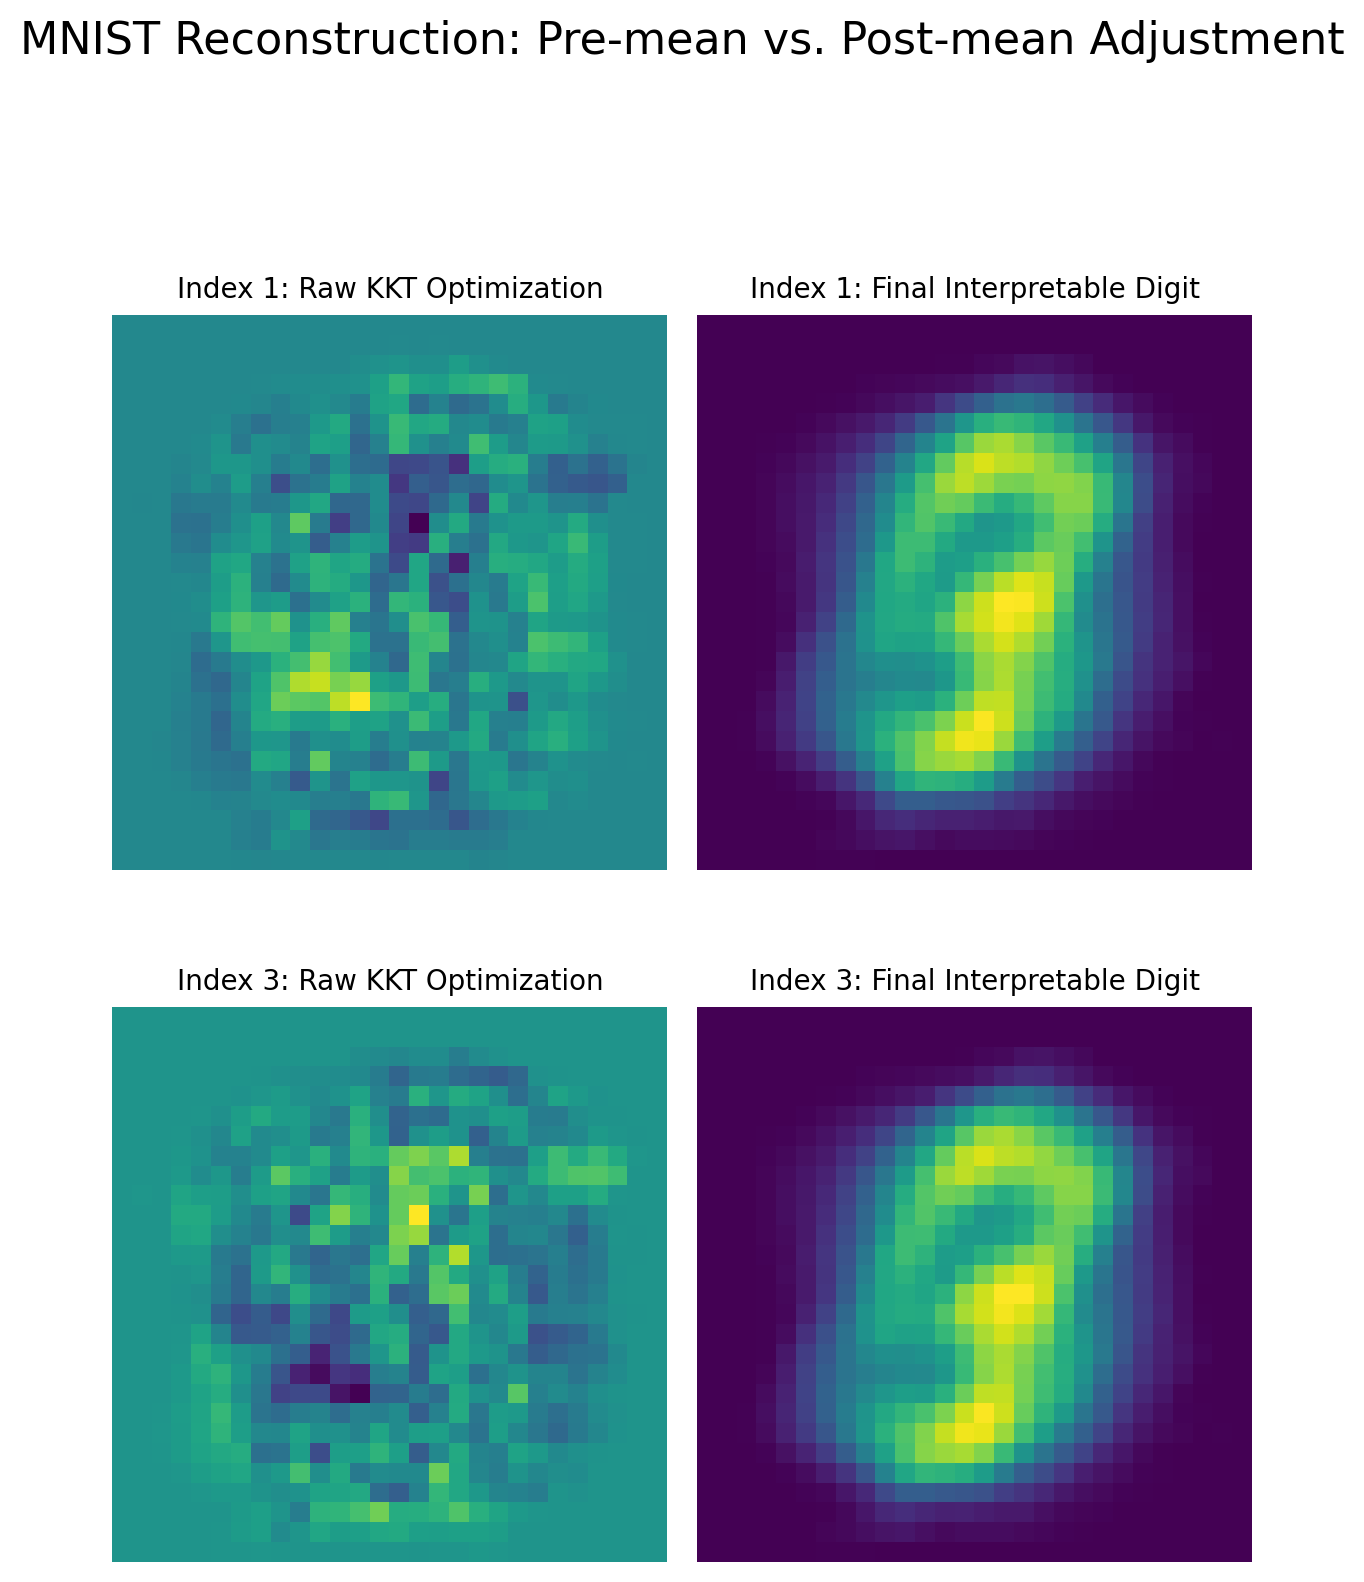

In [24]:
X_raw_tensor = torch.load("./mnist_pth/10000_x1.pth", map_location=device)
X_raw = X_raw_tensor.detach().cpu().numpy()
Xtrn, Ytrn = next(iter(train_loader))
ds_mean = Xtrn.mean(dim=0, keepdims=True).data

X_visualized = (X_raw_tensor + ds_mean).detach().cpu().numpy()
X_raw = X_raw.reshape(1000, 28, 28)
X_visualized = X_visualized.reshape(1000, 28, 28)

indices = [1, 3]
n = len(indices)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(6, 9), dpi=200)

for i, idx in enumerate(indices):
    # Raw Optimization Output
    axes[i, 0].imshow(X_raw[idx])
    axes[i, 0].set_title(f'Index {idx}: Raw KKT Optimization', fontsize=10)
    axes[i, 0].set_ylabel(f'Sample {idx}', fontsize=12)
    axes[i, 0].axis('off')
    
    # Mean-Adjusted Result
    axes[i, 1].imshow(X_visualized[idx])
    axes[i, 1].set_title(f'Index {idx}: Final Interpretable Digit', fontsize=10)
    axes[i, 1].axis('off')

fig.suptitle('MNIST Reconstruction: Pre-mean vs. Post-mean Adjustment', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Old Testing Code

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import datasets, transforms
import copy

# ---------------------------
# 1. Homogeneous MLP (biases only in first layer)
# ---------------------------
class HomogeneousMLP(nn.Module):
    def __init__(self, input_dim=784, hidden1=1000, hidden2=1000):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1, bias=True)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2, bias=False)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, 1, bias=False)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x.squeeze()

# ---------------------------
# 2. Smooth ReLU for reconstruction (forward = ReLU, backward = sigmoid)
# ---------------------------
class smooth_relu(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.save_for_backward(x)
        ctx.alpha = alpha
        return torch.relu(x)

    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        alpha = ctx.alpha
        grad_input = grad_output * torch.sigmoid(alpha * x)
        return grad_input, None

class SmoothReLU(nn.Module):
    def __init__(self, alpha=100):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return smooth_relu.apply(x, self.alpha)

def replace_relu_with_smooth(model, alpha):
    for name, module in model.named_children():
        if isinstance(module, nn.ReLU):
            setattr(model, name, SmoothReLU(alpha))
        else:
            replace_relu_with_smooth(module, alpha)

# ---------------------------
# 3. Data loading (MNIST binary: even=+1, odd=-1)
# ---------------------------
def load_mnist_binary(n_samples=500, normalize=True):
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = datasets.MNIST(root="./data", train=True, transform=transform)

    X, y = [], []
    for img, label in dataset:
        label_bin = 1 if label % 2 == 0 else -1
        X.append(img.view(-1).numpy())
        y.append(label_bin)
        if len(X) >= n_samples:
            break

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    X = torch.from_numpy(X)
    y = torch.from_numpy(y)

    if normalize:
        mean = X.mean(dim=0, keepdim=True)
        X = X - mean   # zero mean, roughly in [-0.5,0.5]
    return X, y

# ---------------------------
# 4. Training (full-batch GD, logistic loss)
# ---------------------------
def train_model(model, X, y, epochs=200000, lr=0.01):
    optimizer = optim.SGD(model.parameters(), lr=lr)
    for epoch in tqdm(range(epochs), desc="Training"):
        optimizer.zero_grad()
        outputs = model(X)
        loss = torch.mean(torch.log(1 + torch.exp(-y * outputs)))
        loss.backward()
        optimizer.step()
        if epoch % 10000 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    return model

# ---------------------------
# 5. Reconstruction with stabilisation
# ---------------------------
def reconstruct(model, n_reconstruct=100, steps=100000, lr=0.001, sigma_x=0.1, alpha_smooth=100, grad_clip=1.0):
    model_smooth = copy.deepcopy(model)
    replace_relu_with_smooth(model_smooth, alpha_smooth)
    model_smooth.eval()

    theta = torch.cat([p.detach().flatten() for p in model.parameters()])
    print(f"||theta|| = {theta.norm().item():.3f}")

    x_hat = torch.randn(n_reconstruct, 784) * sigma_x
    x_hat.requires_grad_(True)
    lambda_i = torch.rand(n_reconstruct) * 0.1
    lambda_i.requires_grad_(True)

    y_hat = torch.cat([torch.ones(n_reconstruct // 2),
                       -torch.ones(n_reconstruct - n_reconstruct // 2)])

    optimizer = optim.SGD([x_hat, lambda_i], lr=lr, momentum=0.9)

    for step in range(steps):
        optimizer.zero_grad()

        outputs = model_smooth(x_hat)
        weighted_sum = torch.sum(lambda_i * y_hat * outputs)

        grads = torch.autograd.grad(weighted_sum, model_smooth.parameters(),
                                    create_graph=True)
        grad_vec = torch.cat([g.flatten() for g in grads])

        L_theta = torch.norm(theta - grad_vec) ** 2
        L_lambda = torch.sum(torch.relu(-lambda_i))
        L_prior = torch.mean(torch.relu(x_hat - 1) + torch.relu(-x_hat - 1))

        loss = L_theta + 5.0 * L_lambda + 1.0 * L_prior

        # Check for NaN before backward
        if torch.isnan(loss):
            print(f"NaN at step {step}")
            break

        loss.backward()

        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_([x_hat, lambda_i], grad_clip)

        optimizer.step()

        with torch.no_grad():
            x_hat.clamp_(-1, 1)

        if step % 5000 == 0:
            print(f"Step {step:6d} | Loss: {loss.item():.3f} | "
                  f"L_theta: {L_theta.item():.3f} | L_lambda: {L_lambda.item():.3f} | "
                  f"L_prior: {L_prior.item():.3f} | ||grad_vec||: {grad_vec.norm().item():.3f}")

    return x_hat.detach(), lambda_i.detach()

# ---------------------------
# 6. Post-processing (filter by λ and remove duplicates)
# ---------------------------
def post_process(x_recon, lambda_i, lambda_thresh=0.01, dist_thresh=2.0):
    keep = lambda_i > lambda_thresh
    x_keep = x_recon[keep]
    if len(x_keep) == 0:
        return x_keep

    x_keep = x_keep.cpu().numpy()
    indices = list(range(len(x_keep)))
    selected = []
    while indices:
        i = indices.pop(0)
        selected.append(x_keep[i])
        dists = np.linalg.norm(x_keep[indices] - x_keep[i], axis=1)
        indices = [idx for j, idx in enumerate(indices) if dists[j] > dist_thresh]
    return torch.tensor(np.array(selected))

# ---------------------------
# 7. Visualization
# ---------------------------
def show_images(images, title="Reconstructed", nrow=10):
    images = images.reshape(-1, 28, 28)
    n = len(images)
    plt.figure(figsize=(nrow, 2))
    for i in range(min(n, nrow)):
        plt.subplot(1, nrow, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

def compare_with_originals(original, reconstructed, n=10):
    original = original.reshape(-1, 28, 28)[:n]
    reconstructed = reconstructed.reshape(-1, 28, 28)[:n]
    plt.figure(figsize=(n, 2.5))
    for i in range(n):
        ax1 = plt.subplot(2, n, i + 1)
        plt.imshow(original[i], cmap='gray')
        plt.axis('off')
        if i == 0:
            ax1.set_title("Original", loc='left')
        ax2 = plt.subplot(2, n, n + i + 1)
        plt.imshow(reconstructed[i], cmap='gray')
        plt.axis('off')
        if i == 0:
            ax2.set_title("Reconstructed", loc='left')
    plt.suptitle("Original vs Reconstructed")
    plt.tight_layout()
    plt.show()

### testing code below

X.mean(): -0.000, X.std(): 0.244


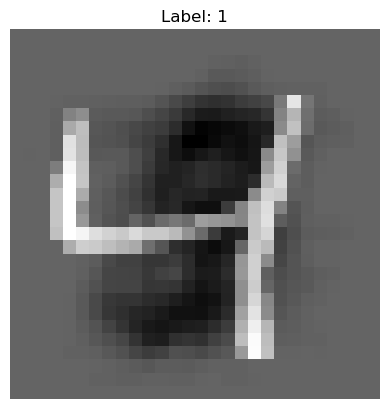

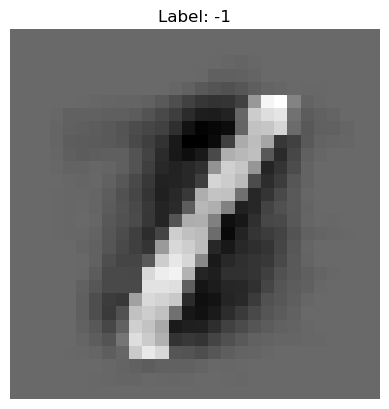

Training model...


Training:   0%|                                                                   | 28/200000 [00:00<23:33, 141.51it/s]

Epoch 0, Loss: 0.693152


Training:   5%|███▏                                                            | 10052/200000 [00:40<12:36, 251.02it/s]

Epoch 10000, Loss: 0.000652


...

Epoch 180000, Loss: 0.000015


Training:  95%|███████████████████████████████████████████████████████████▊   | 190050/200000 [13:12<00:42, 233.28it/s]

Epoch 190000, Loss: 0.000014


Training: 100%|███████████████████████████████████████████████████████████████| 200000/200000 [13:55<00:00, 239.29it/s]



Reconstructing training data...
||theta|| = 18.919
Step      0 | Loss: 483.788 | L_theta: 483.788 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 11.013
Step   5000 | Loss: 335.595 | L_theta: 335.595 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 4.746
Step  10000 | Loss: 334.699 | L_theta: 334.699 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 4.910
Step  15000 | Loss: 334.770 | L_theta: 334.770 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 4.971
Step  20000 | Loss: 334.170 | L_theta: 334.170 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 4.902
Step  25000 | Loss: 334.963 | L_theta: 334.963 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 4.930
Step  30000 | Loss: 334.291 | L_theta: 334.291 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 4.955
Step  35000 | Loss: 334.310 | L_theta: 334.310 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 4.939
Step  40000 | Loss: 334.378 | L_theta: 334.378 | L_lambda: 0.000 | L_prior: 0.000 | ||grad_vec||: 4.930
Step  45000

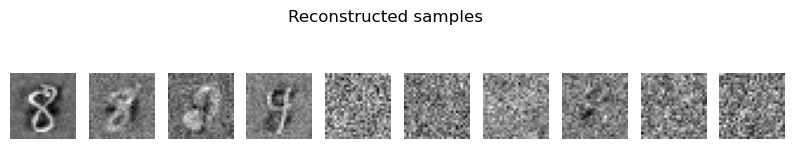

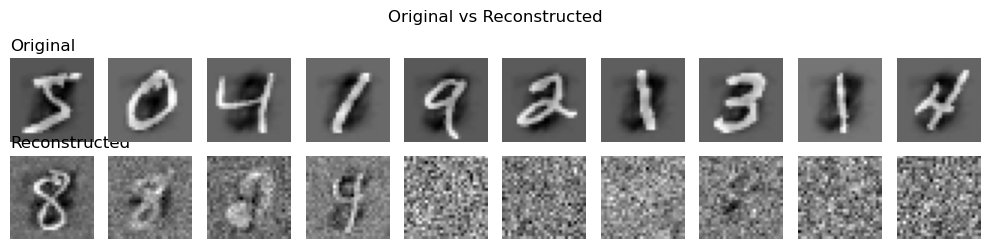

In [2]:
# ---------------------------
# 8. Main script
# ---------------------------
# Load data (small set for quick test)
X, y = load_mnist_binary(n_samples=50, normalize=True)

# Inspect a few samples
print(f"X.mean(): {X.mean():.3f}, X.std(): {X.std():.3f}")
for idx in [2, 3]:
    plt.imshow(X[idx].numpy().reshape(28, 28), cmap='gray')
    plt.title(f"Label: {int(y[idx].item())}")
    plt.axis('off')
    plt.show()

# Initialize model with small first-layer weights
model = HomogeneousMLP(input_dim=784, hidden1=1000, hidden2=1000)
nn.init.normal_(model.fc1.weight, mean=0.0, std=1e-4)
if model.fc1.bias is not None:
    nn.init.zeros_(model.fc1.bias)

# Train
print("Training model...")
model = train_model(model, X, y, epochs=200000, lr=0.01)

# Reconstruct with stabilised parameters
print("\nReconstructing training data...")
x_recon, lambda_i = reconstruct(model,
                                n_reconstruct=100,
                                steps=50000,
                                lr=0.01,
                                sigma_x=0.1,
                                alpha_smooth=100,
                                grad_clip=1.0)     # gradient clipping

# Post-process
x_filtered = post_process(x_recon, lambda_i, lambda_thresh=0.01, dist_thresh=2.0)
print(f"Kept {len(x_filtered)} samples after filtering")

if len(x_filtered) > 0:
    x_display = (x_filtered - x_filtered.min()) / (x_filtered.max() - x_filtered.min() + 1e-8)
    show_images(x_display, title="Reconstructed samples")
    compare_with_originals(X[:10], x_display[:10])
else:
    print("No samples survived filtering. Try lowering lambda_thresh or check optimization.")

In [6]:
x_display_test = (x_filtered - x_filtered.min()) / (x_filtered.max() - x_filtered.min() + 1e-8)

In [11]:
print(np.arange(len(x_filtered)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]


In [12]:
print(np.arange(len(X)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


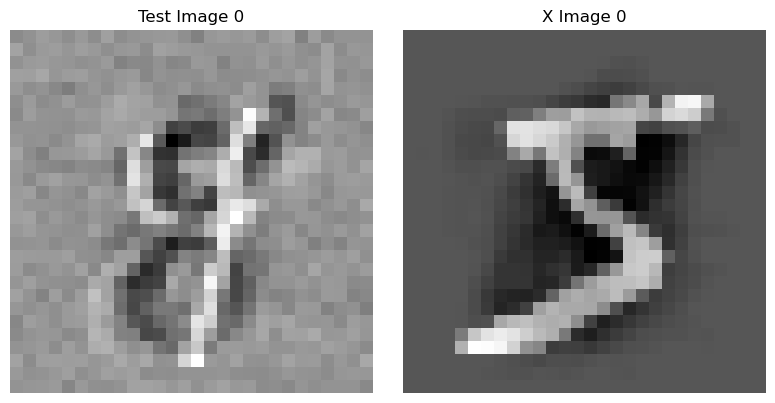

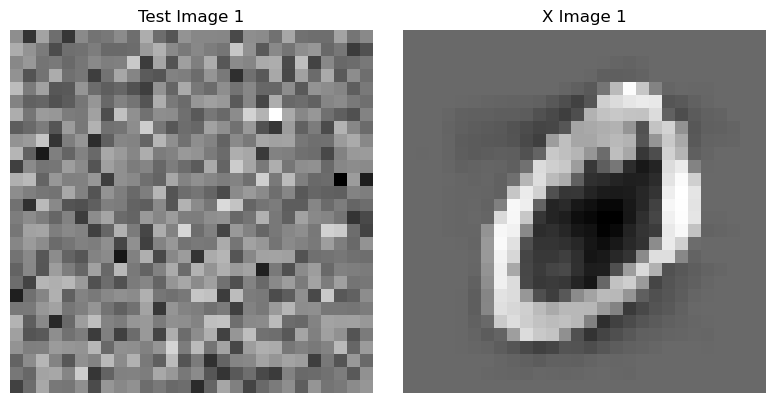

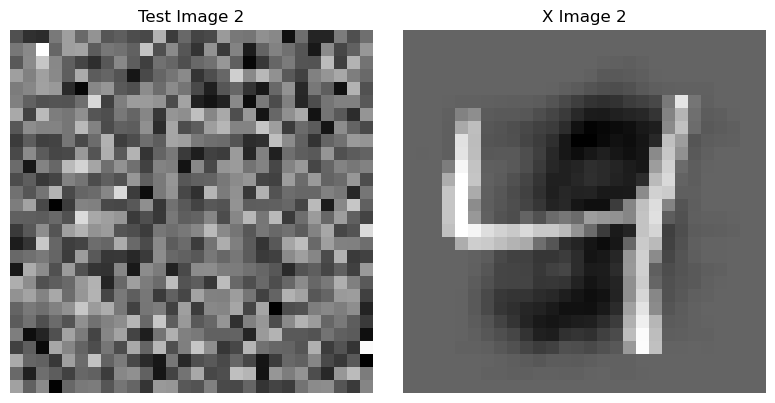

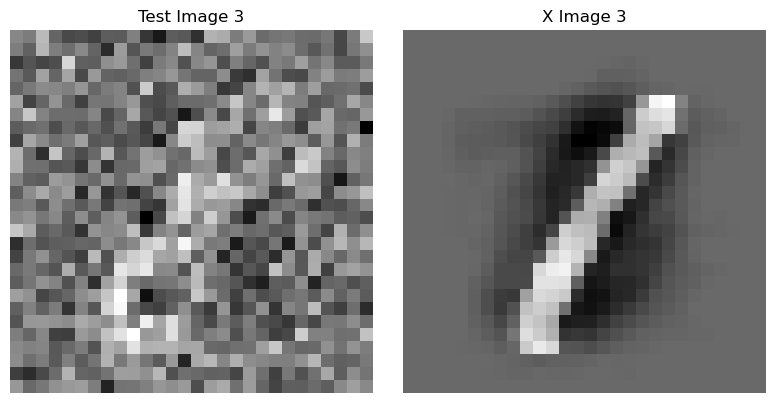

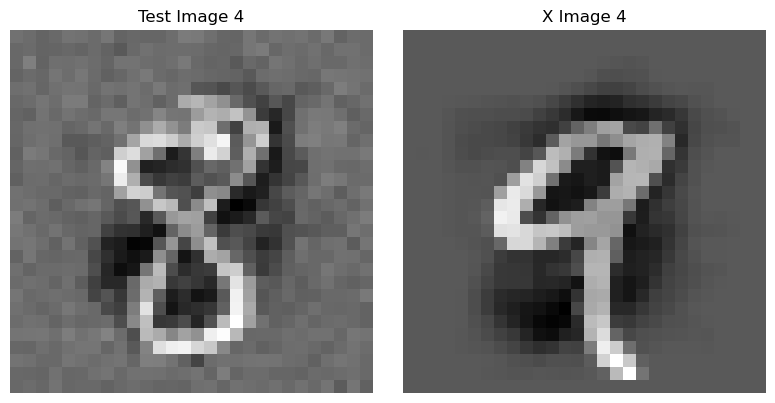

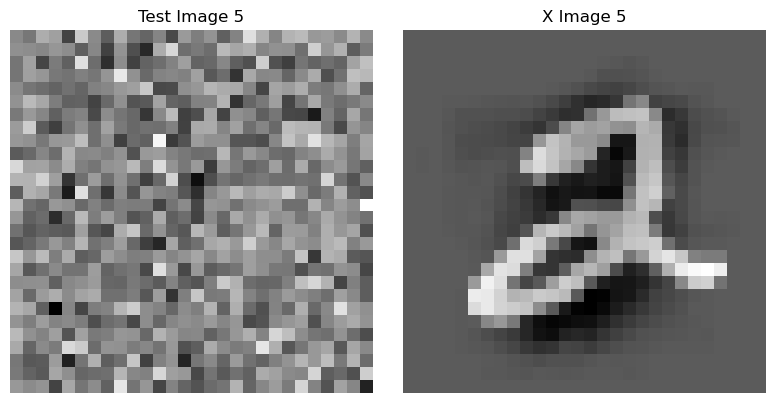

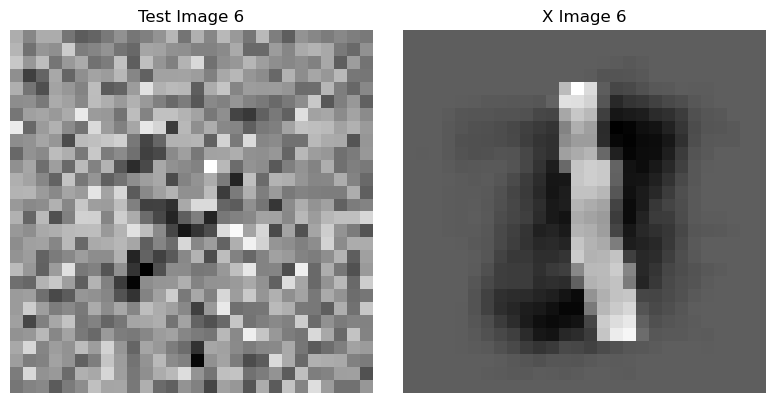

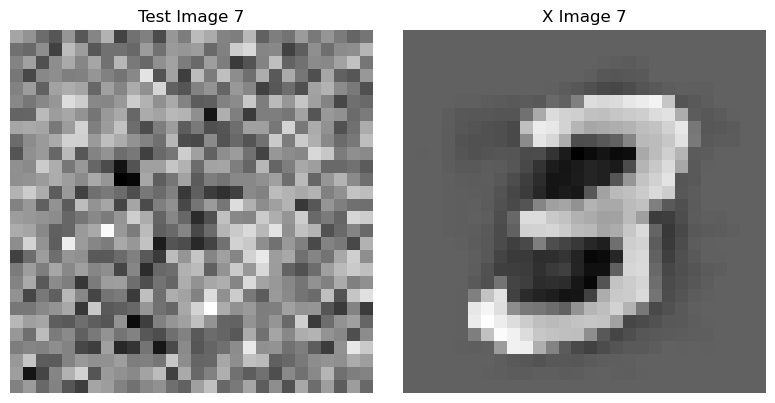

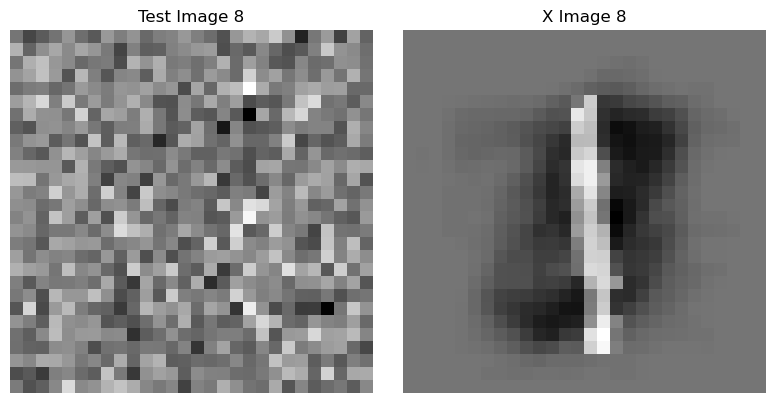

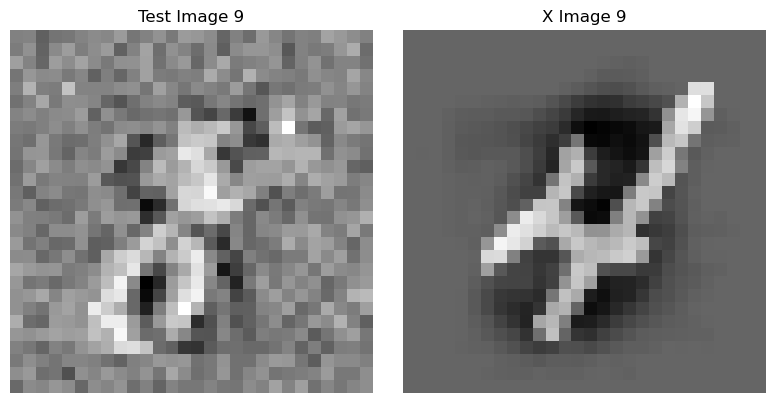

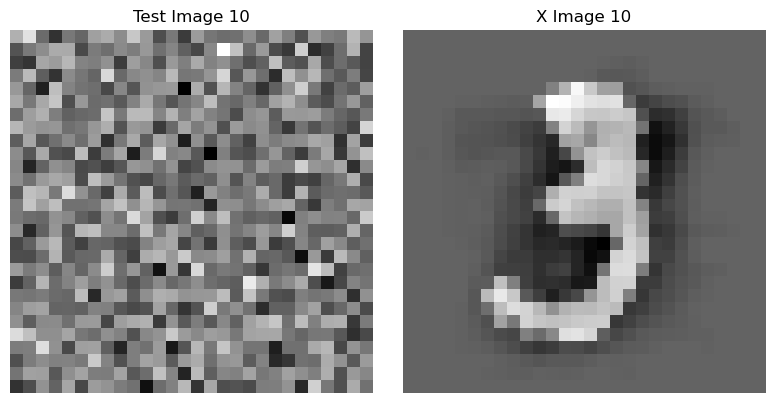

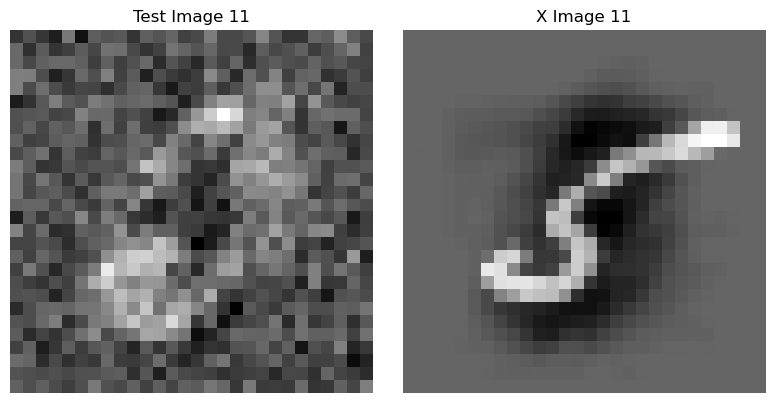

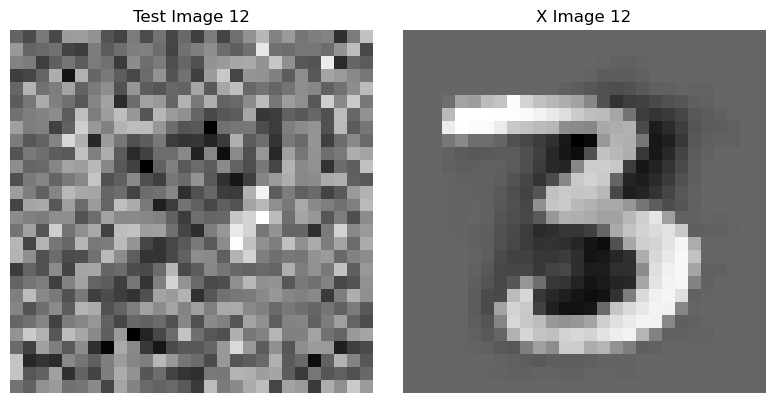

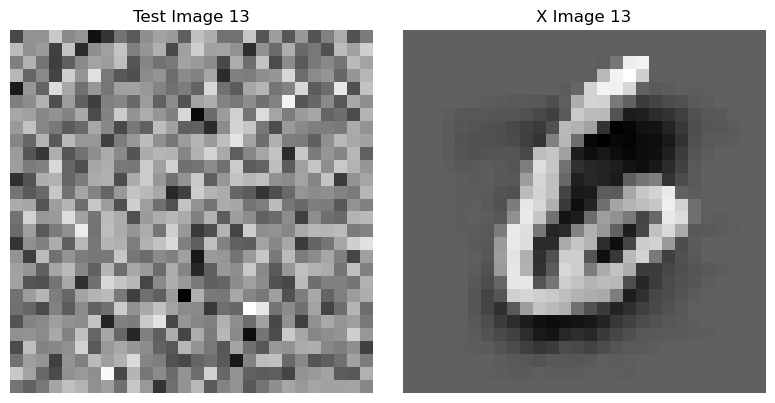

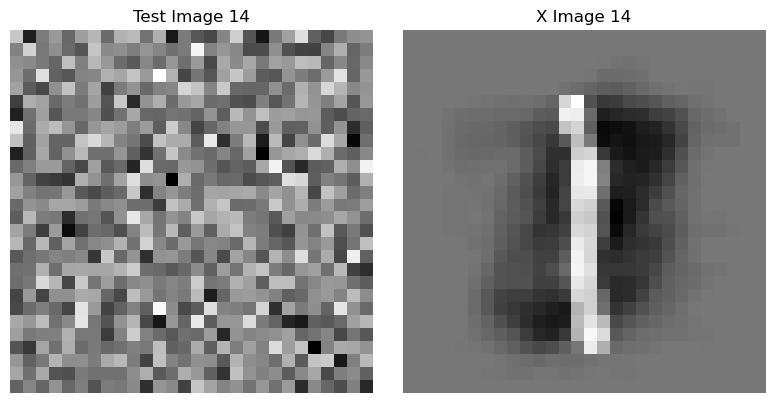

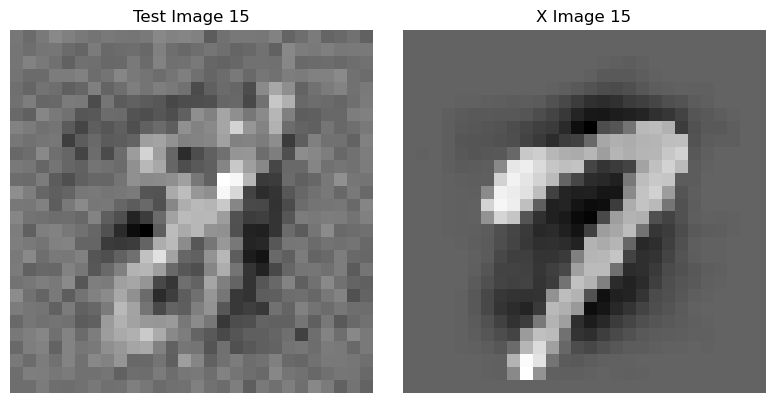

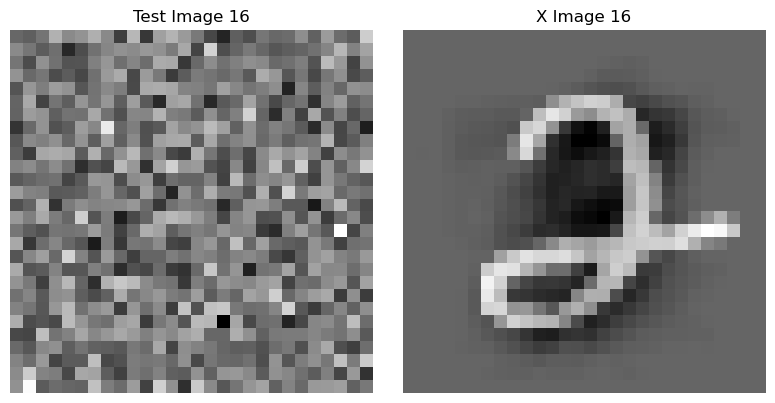

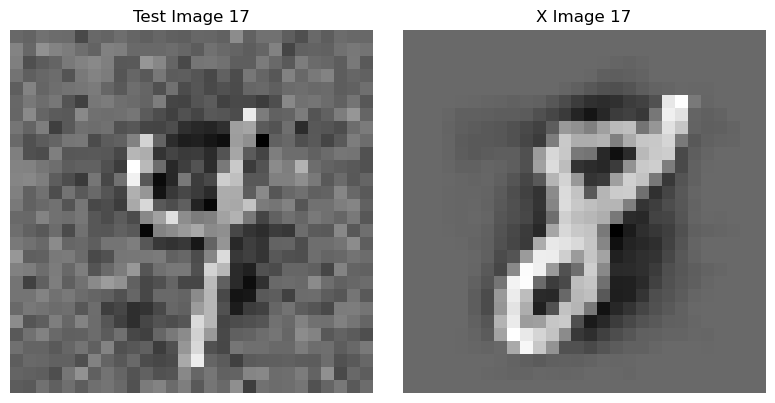

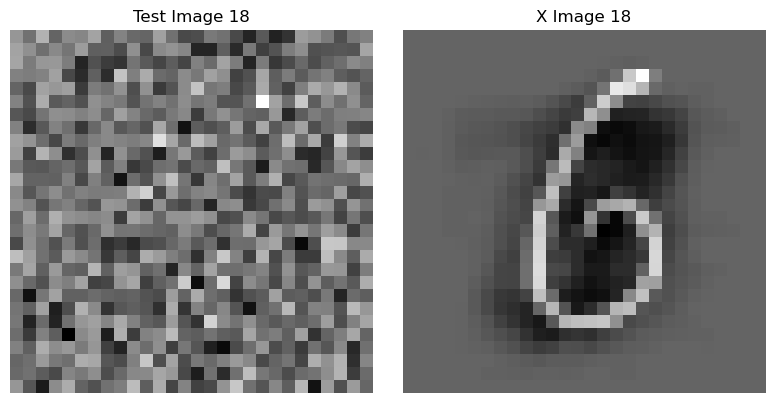

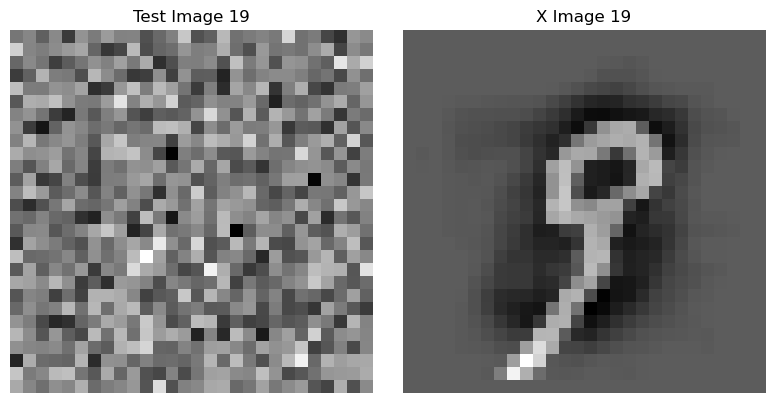

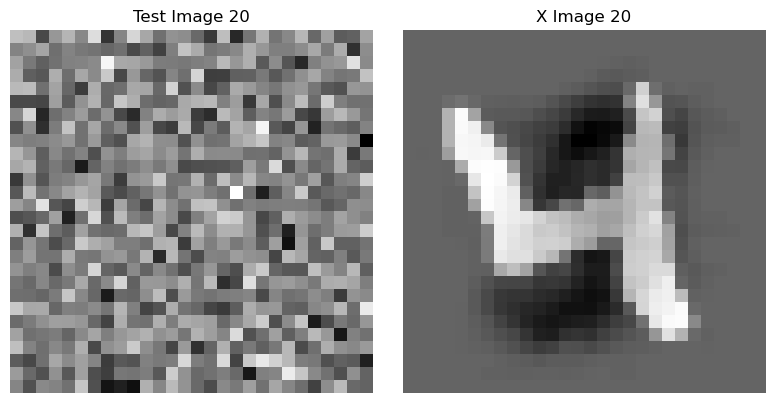

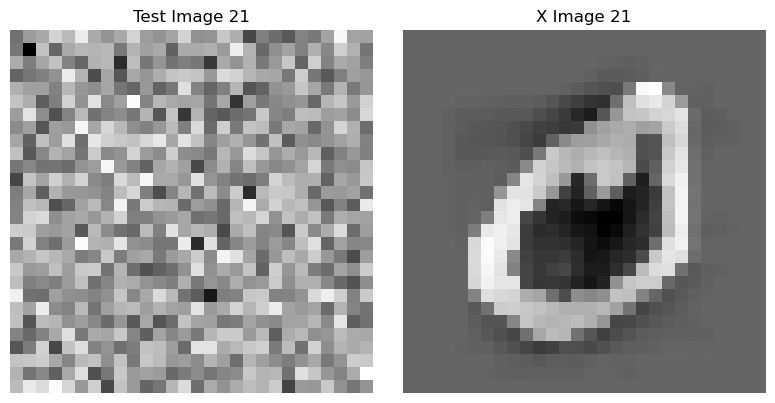

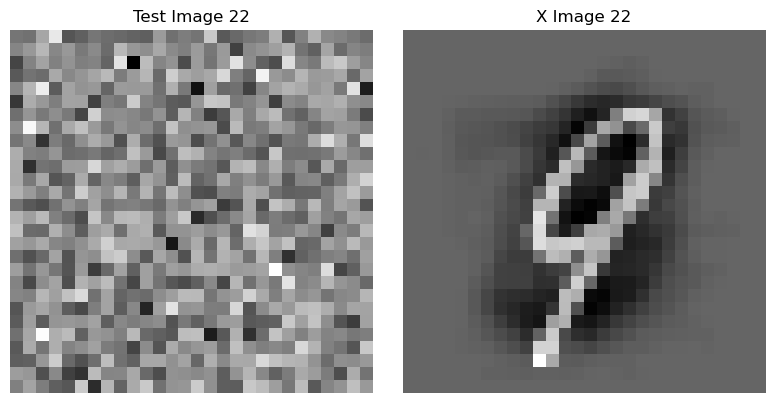

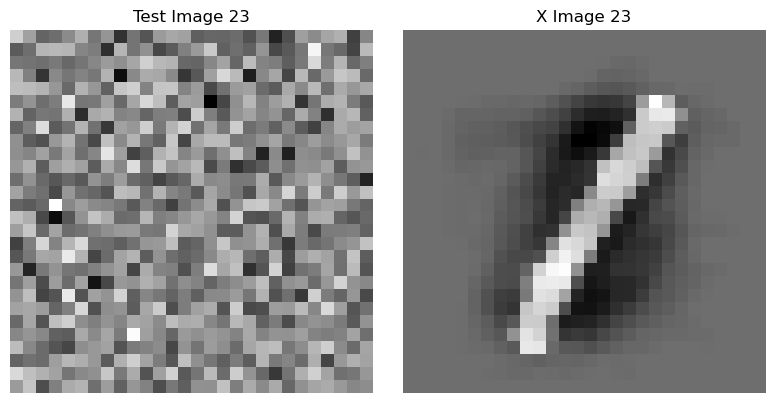

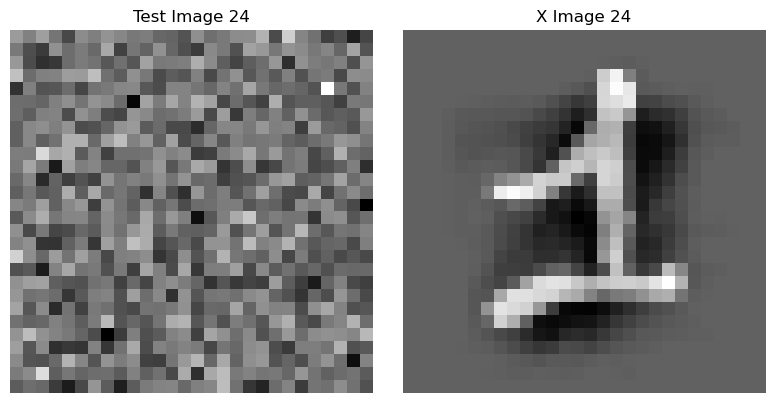

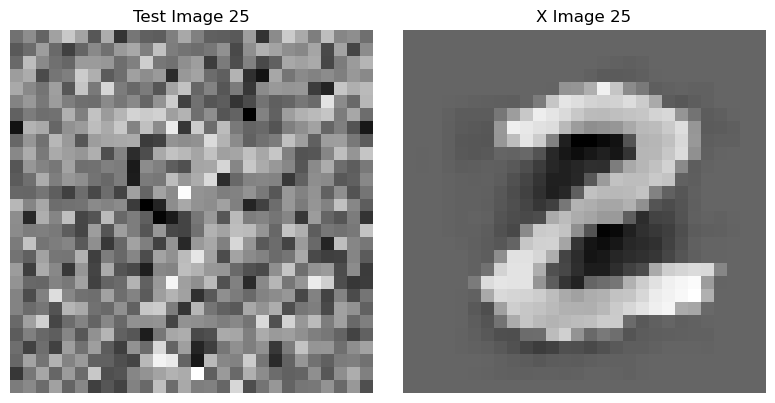

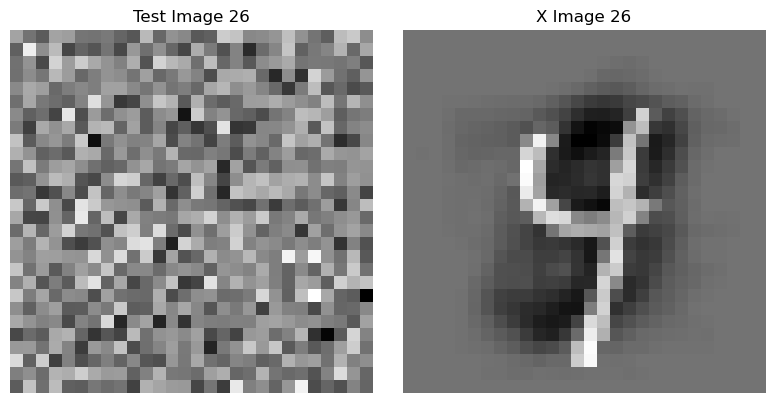

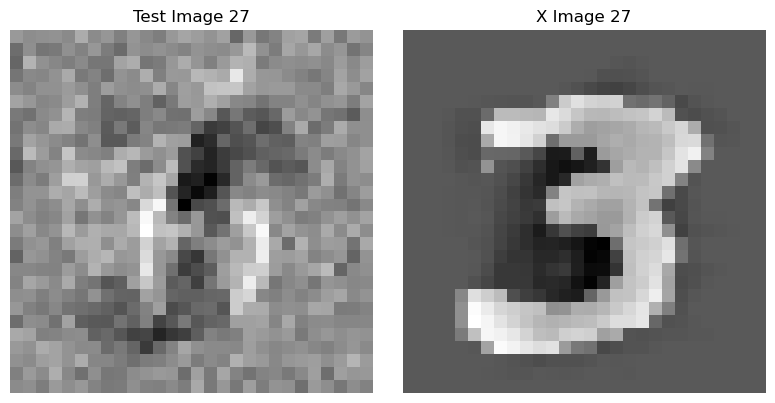

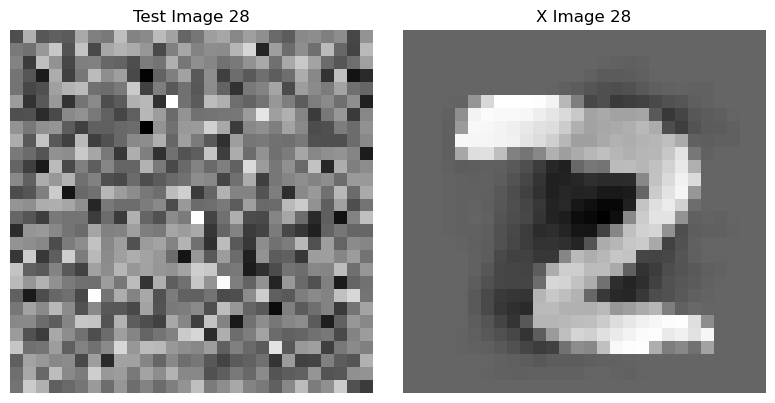

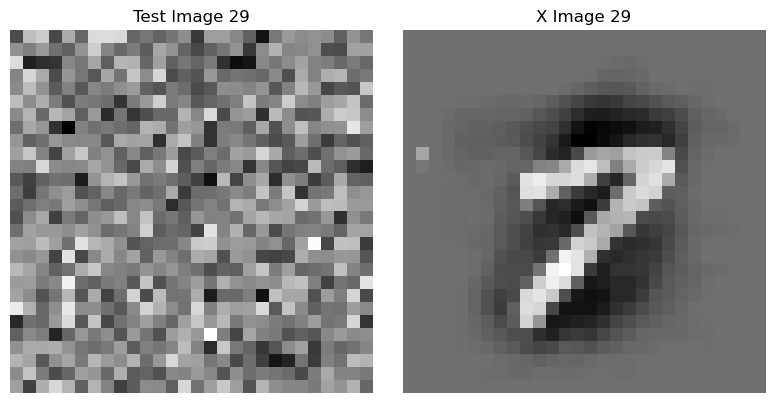

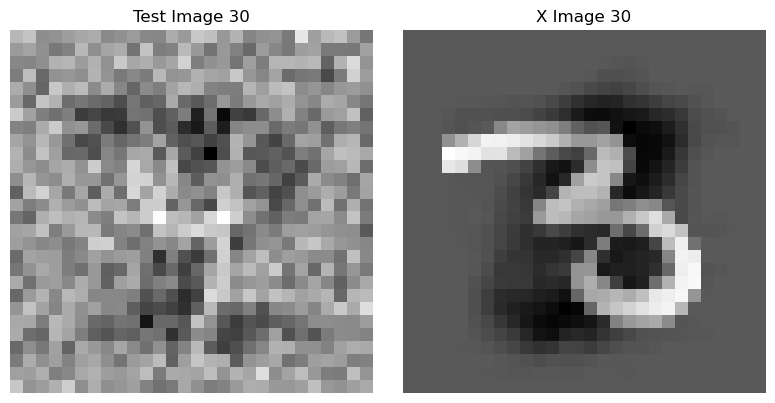

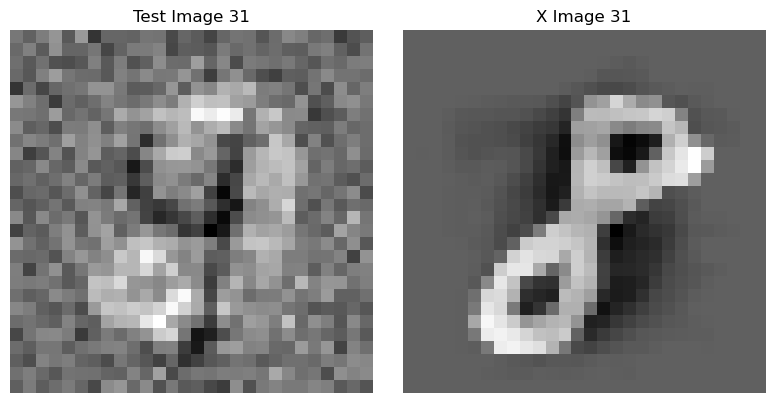

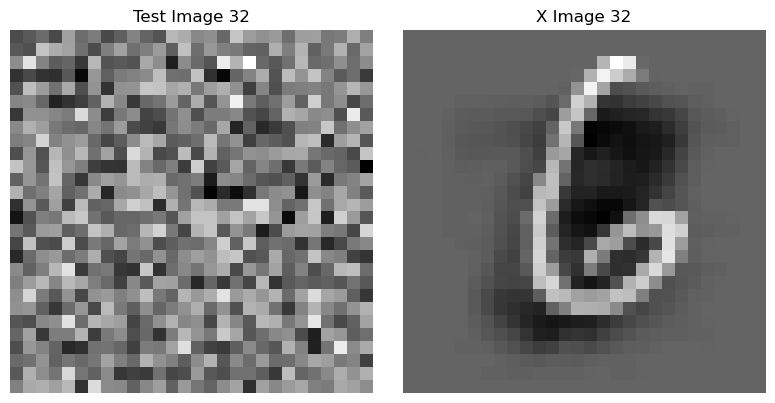

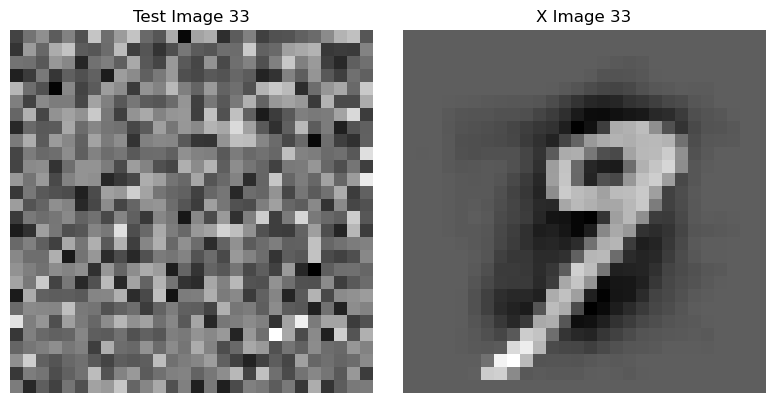

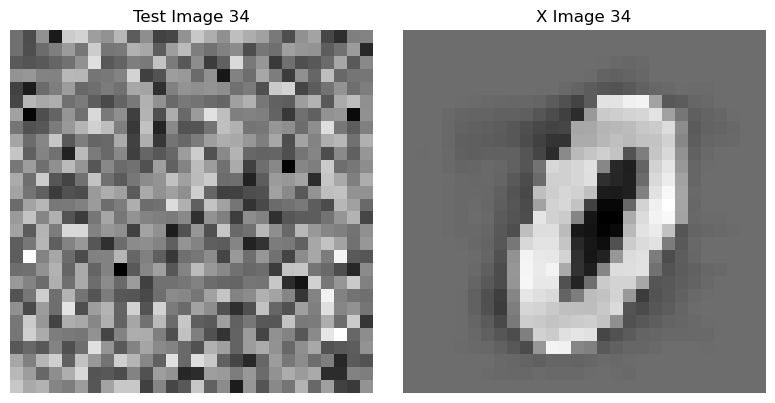

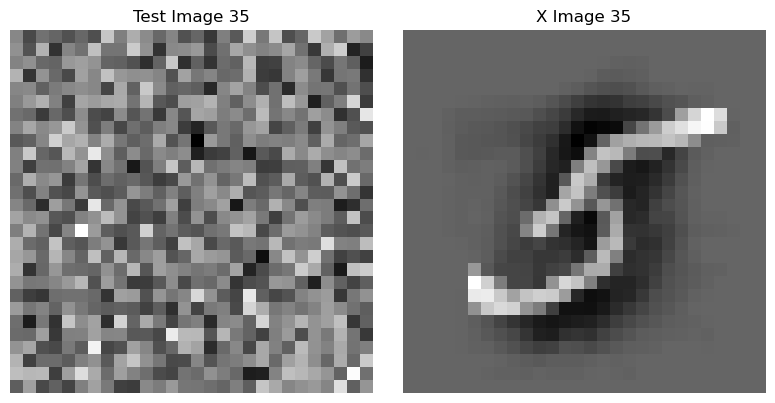

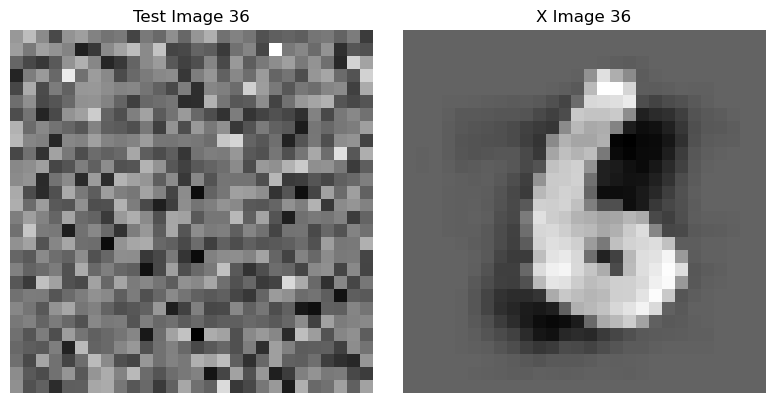

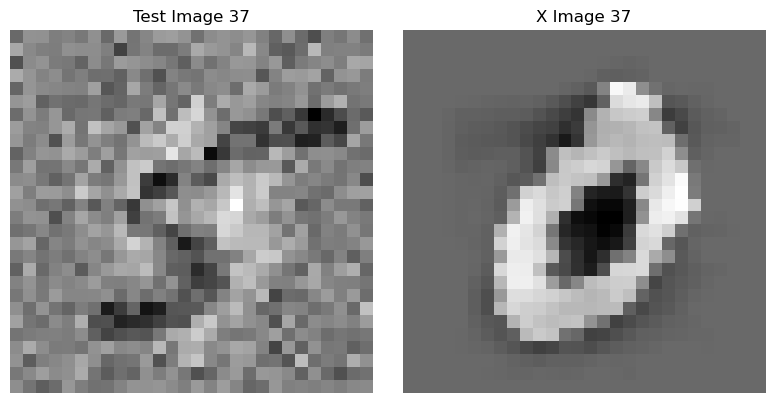

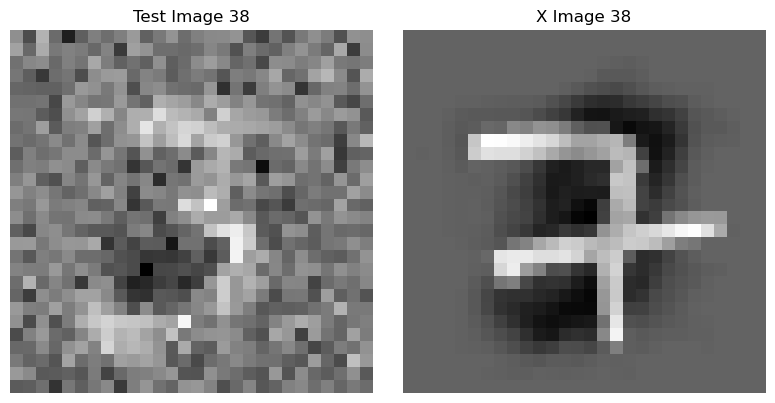

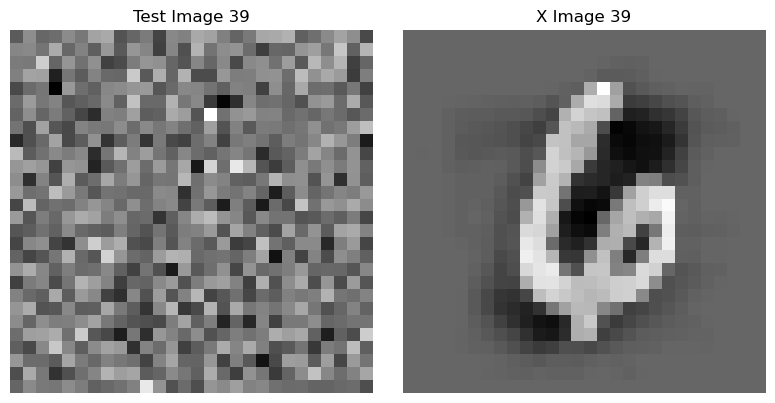

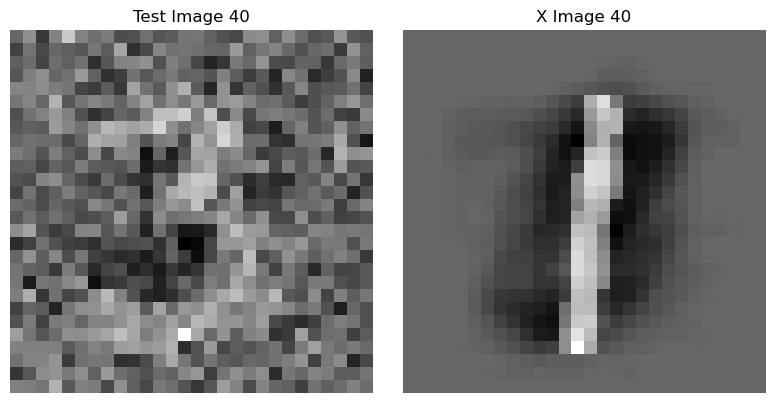

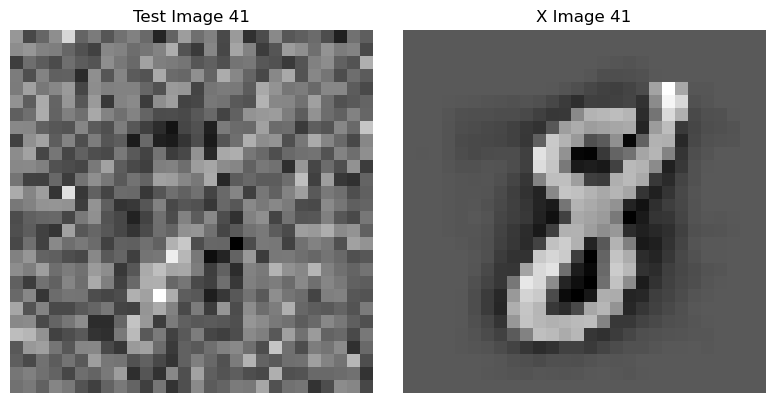

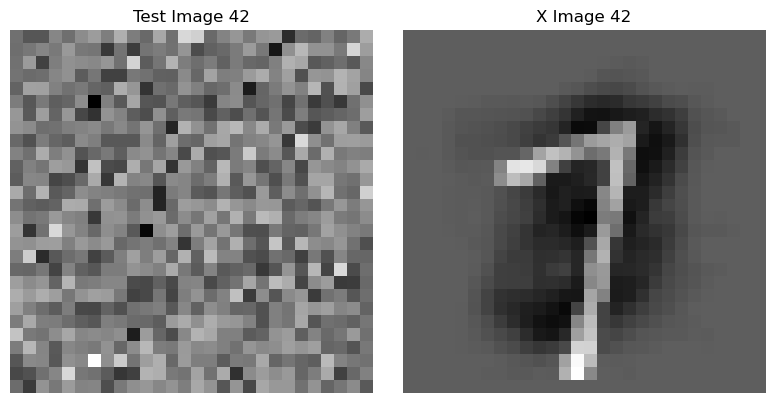

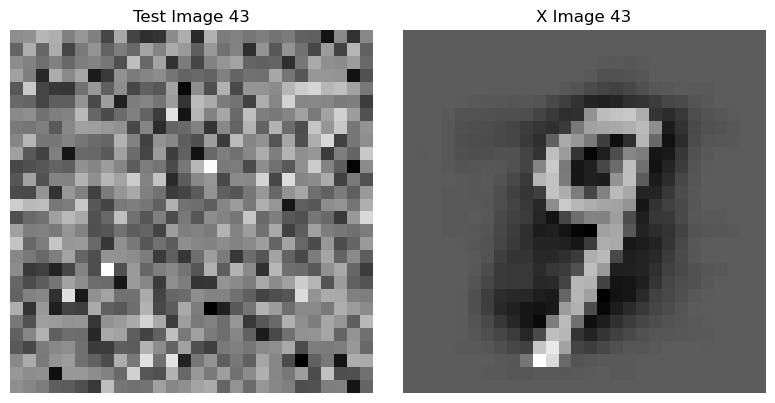

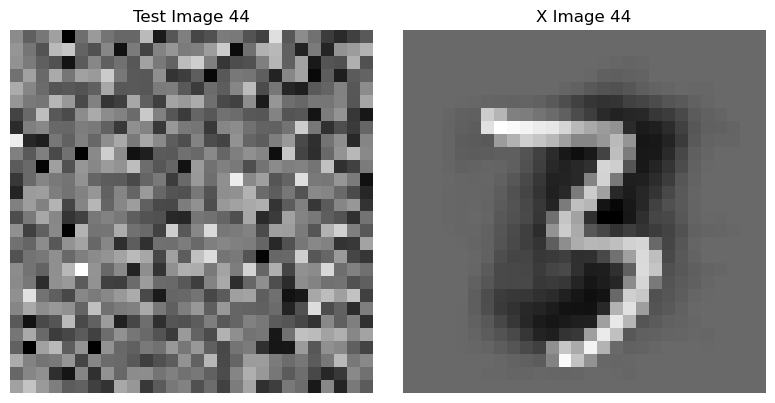

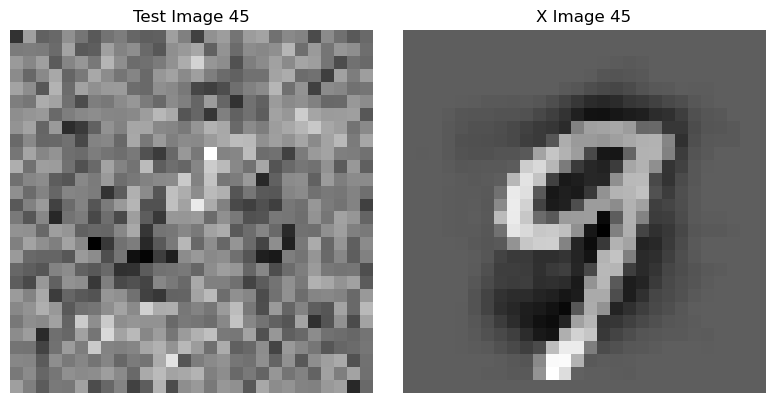

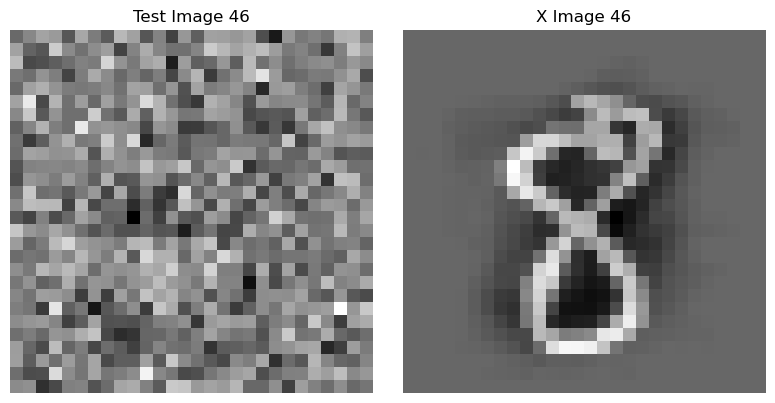

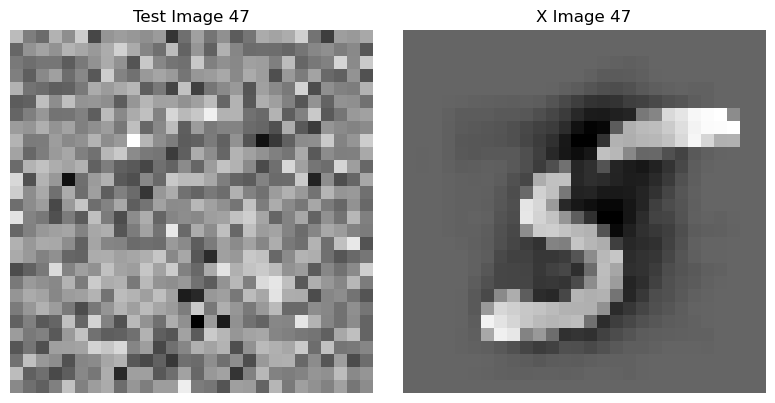

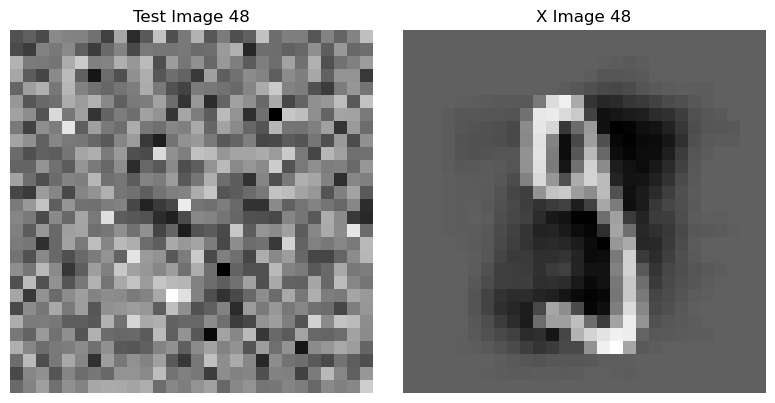

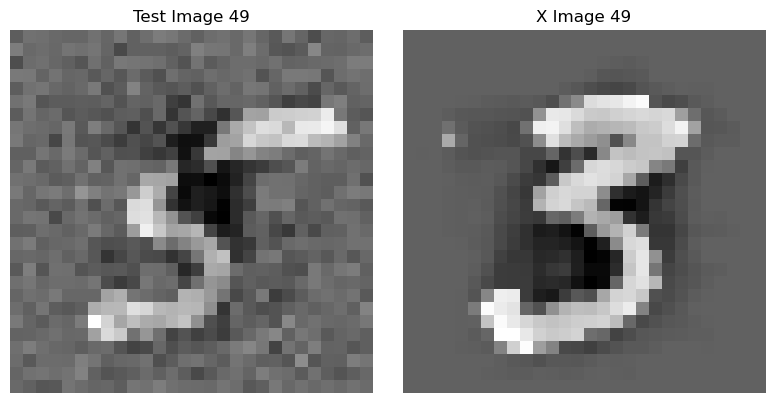

In [13]:
import matplotlib.pyplot as plt

num_images = min(len(X), len(x_filtered))
for idx in range(num_images):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(x_display_test[idx].numpy().reshape(28, 28), cmap='gray')
    axes[0].set_title(f"Test Image {idx}")
    axes[0].axis('off')
    axes[1].imshow(X[idx].numpy().reshape(28, 28), cmap='gray')
    axes[1].set_title(f"X Image {idx}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()